In [1]:
import math
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from scipy import stats
import statistics

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns


#from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans,DBSCAN
#from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator
#from sklearn.ensemble import RandomForestClassifier
#from sklearn.svm import SVC
#from sklearn.linear_model import LogisticRegression

In [2]:
import tcremp.TCRemP as TCRemP
import tcremp.TCRemP_clstr as TCRemP_clstr
import tcremp.TCRemP_clstr_pred as TCRemP_clstr_pred
#import tcremp.TCRemP_upd as TCRemP
import tcremp.ml_utils as ml_utils
import tcremp.data_proc as data_proc
import tcremp.metrics as metrics

In [3]:

import warnings
warnings.filterwarnings('ignore')



# Paths

In [4]:
#run_name = 'vdjdb_210124'
#run_name_100 = 'vdjdb_100p'
run_name = 'vdjdb_paired'
#raw_train_data_path = 'data/vdjdb.slim.txt'

In [5]:
label = 'antigen.epitope'
label_high = str(label + '_freq')
label_s = 'antigen.species'
label_high_s = str(label_s + '_freq')
tcr_columns = {'single': ['cdr3aa','v','j','chain'],'paired': {'TRA': ['a_cdr3aa', 'TRAV', 'TRAJ'],'TRB': [ 'b_cdr3aa', 'TRBV', 'TRBJ']}}
#tcr_columns = ['cdr3aa','v','j','chain']
clonotype_id_column = 'cloneId'
clonotype_index= 'clonotype_index'
annotation_id = 'annotId'
pairing_id = 'barcode'
annotation_tcr_id_columns_dict = {'TRA': 'cloneId','TRB': 'cloneId','TRA_TRB': {'TRA':'cloneId_TRA', 'TRB':'cloneId_TRB'}}

In [6]:
outputs_path = "tcremp_outputs/" + run_name + '/'
Path(outputs_path).mkdir(parents=True, exist_ok=True)

In [7]:

data_prebuilt_path = 'data/data_prebuilt/VDJdb_data_paired.csv'

# Data upload

In [8]:
data_prebuilt = pd.read_csv(data_prebuilt_path,sep='\t')

In [9]:
data_prebuilt

,a_cdr3aa,a_v,a_j,b_cdr3aa,b_v,d.beta,b_j,species,mhc.a,mhc.b,mhc.class,antigen.epitope,antigen.gene,antigen.species,reference.id,clonotype_index,antigen.epitope_freq,antigen.species_freq
0,CIVRAPGRADMRF,TRAV26-1*01,TRAJ43*01,CASSYLPGQGDHYSNQPQHF,TRBV13*01,NaN,TRBJ1-5*01,HomoSapiens,HLA-B*08,B2M,MHCI,FLKEKGGL,Nef,HIV-1,PMID:15596521,0,other,HIV-1
1,NaN,NaN,NaN,CASSFEAGQGFFSNQPQHF,TRBV13*01,NaN,TRBJ1-5*01,HomoSapiens,HLA-B*08,B2M,MHCI,FLKEKGGL,Nef,HIV-1,PMID:15596521,1,other,HIV-1
2,CAVPSGAGSYQLTF,TRAV20*01,TRAJ28*01,CASSFEPGQGFYSNQPQHF,TRBV13*01,NaN,TRBJ1-5*01,HomoSapiens,HLA-B*08,B2M,MHCI,FLKEKGGL,Nef,HIV-1,PMID:15596521,2,other,HIV-1
3,CAVKASGSRLT,TRAV2*01,NaN,CASSYEPGQVSHYSNQPQHF,TRBV13*01,NaN,TRBJ1-5*01,HomoSapiens,HLA-B*08,B2M,MHCI,FLKEKGGL,Nef,HIV-1,PMID:15596521,3,other,HIV-1
4,CAYRPPGTYKYIF,TRAV38-2/DV8*01,TRAJ40*01,CASSALASLNEQFF,TRBV14*01,NaN,TRBJ2-1*01,HomoSapiens,HLA-B*08,B2M,MHCI,FLKEKGGL,Nef,HIV-1,PMID:15596521,4,other,HIV-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36622,CMDEGGSNYKLTF,TRAV26-1*01,TRAJ53*01,CASSVRSTDTQYF,TRBV7-2*01,NaN,TRBJ2-3*01,HomoSapiens,HLA-DQA1*05:01,HLA-DQB1*02:01,MHCII,PQPELPYPQPQL,Gluten,Wheat,PMID:33927715,62172,other,Wheat
36623,CSLYNNNDMRF,TRAV26-1*01,TRAJ43*01,CASSLRYTDTQYF,TRBV7-2*01,NaN,TRBJ2-3*01,HomoSapiens,HLA-DQA1*05:01,HLA-DQB1*02:01,MHCII,PQPELPYPQPQL,Gluten,Wheat,PMID:33927715,62173,other,Wheat
36624,CALSTDSWGKLQF,TRAV6*01,TRAJ24*01,CASSPGQGGDNEQFF,TRBV7-3*01,NaN,TRBJ2-1*01,HomoSapiens,HLA-DQA1*05:01,HLA-DQB1*02:01,MHCII,PQQPFPQPEQPFP,Gluten,Wheat,PMID:33927715,62174,other,Wheat
36625,CAPQGATNKLIF,TRAV12-2*01,TRAJ32*01,CASSLGAGGQETQYF,TRBV5-1*01,NaN,TRBJ2-5*01,HomoSapiens,HLA-DQA1*05:01,HLA-DQB1*02:01,MHCII,PQQPFPQPEQPFP,Gluten,Wheat,PMID:33927715,62175,other,Wheat


# data overview

# TCRemP module

In [12]:
unique_clonotypes = True

In [13]:
tcremp = TCRemP.TCRemP(outputs_path, data_prebuilt)

In [ ]:

tcremp.tcremp_clonotypes('TRA', unique_clonotypes=unique_clonotypes)
tcremp.tcremp_clonotypes('TRB', unique_clonotypes=unique_clonotypes)
#tcremp.tcremp_dists_count('TRA')
#tcremp.tcremp_dists_count('TRB')
tcremp.tcremp_dists('TRA')
tcremp.tcremp_dists('TRB')
tcremp.tcremp_pca('TRA')
tcremp.tcremp_pca('TRB')
tcremp.tcremp_tsne('TRA')
tcremp.tcremp_tsne('TRB')

In [13]:
tcremp.tcremp_clonotypes('TRA_TRB', unique_clonotypes=unique_clonotypes)
#tcremp.tcremp_dists_count('TRA_TRB')
tcremp.tcremp_dists('TRA_TRB')
tcremp.tcremp_pca('TRA_TRB')
tcremp.tcremp_tsne('TRA_TRB')

2024-06-12 06:07:30
Clonotypes extraction time: 0.41303515434265137
dist_proc: 22.04622530937195
pca: 10.507179737091064
tsne: 23.987172603607178


In [ ]:
tcremp.pca_clones['TRA']

In [14]:
vdjdb_data = tcremp.annot['TRA'][tcr_columns['paired']['TRA'] + [label_high,label
                                                , 'antigen.species','mhc.a','mhc.b', 'mhc.class','cloneId'
                                                ,clonotype_index]].rename({'clonotype_index':'vdjdb_clonotype_index','cloneId':'vdjdb_cloneId'},axis=1).reset_index(drop=True)
vdjdb_data.to_csv('data/VDJdb_pred/vdjdb_data_with_cloneId_TRA.txt',sep='\t',index=False)
print(list(vdjdb_data['antigen.epitope_freq'].drop_duplicates()))
vdjdb_data.groupby('antigen.epitope_freq')['vdjdb_clonotype_index'].count()

['other', 'ELAGIGILTV', 'KRWIILGLNK', 'PKYVKQNTLKLAT', 'GILGFVFTL', 'NLVPMVATV', 'GLCTLVAML', 'YLQPRTFLL', 'LLLGIGILV', 'NEGVKAAW', 'LLWNGPMAV', 'CINGVCWTV', 'TFEYVSQPFLMDLE', 'FRDYVDRFYKTLRAEQASQE', 'TTDPSFLGRY', 'SPRWYFYYL']


antigen.epitope_freq
CINGVCWTV                186
ELAGIGILTV                56
FRDYVDRFYKTLRAEQASQE     153
GILGFVFTL               2402
GLCTLVAML                155
KRWIILGLNK                 4
LLLGIGILV                314
LLWNGPMAV                246
NEGVKAAW                 122
NLVPMVATV               2093
PKYVKQNTLKLAT            106
SPRWYFYYL                352
TFEYVSQPFLMDLE            93
TTDPSFLGRY               280
YLQPRTFLL                583
other                   3148
Name: vdjdb_data_id, dtype: int64

In [15]:
vdjdb_data = tcremp.annot['TRB'][tcr_columns['paired']['TRB'] + [label_high,label
                                                , 'antigen.species','mhc.a','mhc.b', 'mhc.class','cloneId'
                                                ,clonotype_index]].rename({clonotype_index:'vdjdb_clonotype_index','cloneId':'vdjdb_cloneId'},axis=1).reset_index(drop=True)
vdjdb_data.to_csv('data/VDJdb_pred/vdjdb_data_with_cloneId_TRB.txt',sep='\t',index=False)
vdjdb_data.groupby('antigen.epitope_freq')['vdjdb_clonotype_index'].count()
print(list(vdjdb_data['antigen.epitope_freq'].drop_duplicates()))
vdjdb_data.groupby('antigen.epitope_freq')['vdjdb_clonotype_index'].count()

['other', 'ELAGIGILTV', 'KRWIILGLNK', 'NLVPMVATV', 'PKYVKQNTLKLAT', 'GILGFVFTL', 'GLCTLVAML', 'YLQPRTFLL', 'LLWNGPMAV', 'LLLGIGILV', 'NEGVKAAW', 'CINGVCWTV', 'TFEYVSQPFLMDLE', 'FRDYVDRFYKTLRAEQASQE', 'TTDPSFLGRY', 'SPRWYFYYL']


antigen.epitope_freq
CINGVCWTV                338
ELAGIGILTV              1105
FRDYVDRFYKTLRAEQASQE     386
GILGFVFTL               3003
GLCTLVAML                974
KRWIILGLNK               468
LLLGIGILV                233
LLWNGPMAV                409
NEGVKAAW                 118
NLVPMVATV               4730
PKYVKQNTLKLAT            388
SPRWYFYYL                540
TFEYVSQPFLMDLE           452
TTDPSFLGRY               420
YLQPRTFLL                937
other                   9447
Name: vdjdb_data_id, dtype: int64

In [16]:
vdjdb_data = tcremp.annot['TRA_TRB'][tcr_columns['paired']['TRA'] + tcr_columns['paired']['TRB'] + [label_high,label
                                                , 'antigen.species','mhc.a','mhc.b', 'mhc.class','cloneId','cloneId_TRA','cloneId_TRB'
                                                ,clonotype_index]].rename({clonotype_index:'vdjdb_clonotype_index','cloneId':'vdjdb_cloneId','cloneId_TRA':'vdjdb_cloneId_TRA','cloneId_TRB':'vdjdb_cloneId_TRB'},axis=1).reset_index(drop=True)
vdjdb_data.to_csv('data/VDJdb_pred/vdjdb_data_with_cloneId_TRA_TRB.txt',sep='\t',index=False)
vdjdb_data.groupby('antigen.epitope_freq')['vdjdb_clonotype_index'].count()

antigen.epitope_freq
CINGVCWTV          164
ELAGIGILTV          48
GILGFVFTL          511
GLCTLVAML          134
LLWNGPMAV          182
NLVPMVATV          260
PKYVKQNTLKLAT       39
SPRWYFYYL          248
TFEYVSQPFLMDLE     353
TTDPSFLGRY         221
YLQPRTFLL          178
other             2067
Name: vdjdb_data_id, dtype: int64

In [25]:
vdjdb_data[vdjdb_data['vdjdb_cloneId_TRA']==749]

,a_cdr3aa,TRAV,TRAJ,b_cdr3aa,TRBV,TRBJ,antigen.epitope_freq,antigen.epitope,antigen.species,mhc.a,mhc.b,mhc.class,vdjdb_cloneId,vdjdb_cloneId_TRA,vdjdb_cloneId_TRB,vdjdb_data_id
2050,CAENSGGGSQGNLIF,TRAV13-2,TRAJ42,CASSFRATDTQYF,TRBV19,TRBJ2-3,GILGFVFTL,GILGFVFTL,InfluenzaA,HLA-A*02:01,B2M,MHCI,865,749,1395,23447
2096,CAENSGGGSQGNLIF,TRAV13-2,TRAJ42,CASSFRATDTQYF,TRBV19,TRBJ2-3,GILGFVFTL,GILGFVFTL,InfluenzaA,HLA-A*02:01,B2M,MHCI,865,749,1395,23493


# Analysis

In [ ]:
label_freq_list = list(data_prebuilt[label_high].drop_duplicates().sort_values())
custom_palette = ml_utils.make_custom_palette(label_freq_list)

In [ ]:
fig = plt.figure(figsize=(30,20))

delta_x=-0.01
delta_y=1.1
font_size=20


gs00 = fig.add_gridspec(6, 12)

ax1 = fig.add_subplot(gs00[:2, :3])
ax2 = fig.add_subplot(gs00[3:5, :3])
ax3 = fig.add_subplot(gs00[:2, 4:7])
ax4 = fig.add_subplot(gs00[3:5, 4:7])
ax5 = fig.add_subplot(gs00[:2, 8:11])
ax6 = fig.add_subplot(gs00[3:5, 8:11])


chain = 'TRA'
ml_utils.tsne_plot(pd.merge(tcremp.tsne_clones[chain],tcremp.annot[chain]), label_high, f'VDJdb,{chain}, TSNE colored by {label_high}', to_size = 'clone_size',custom_palette=custom_palette, ax=ax1)

ax1.text(delta_x, delta_y, 'A',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax1.transAxes,
        size=font_size)
#ax1.set_title('tcr counts for each epitope')

ml_utils.tsne_plot(pd.merge(tcremp.tsne_clones[chain],tcremp.annot[chain]), label_high_s, f'VDJdb,{chain}, TSNE colored by {label_high_s}', to_size = 'clone_size', ax=ax2)
ax2.text(delta_x, delta_y, 'B',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax2.transAxes,
        size=font_size)
#ax2.set_title('top count epitopes')

chain = 'TRB'
ml_utils.tsne_plot(pd.merge(tcremp.tsne_clones[chain],tcremp.annot[chain]), label_high, f'VDJdb,{chain}, TSNE colored by {label_high}', to_size = 'clone_size',custom_palette=custom_palette, ax=ax3)

ax3.text(delta_x, delta_y, 'C',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax3.transAxes,
        size=font_size)

ml_utils.tsne_plot(pd.merge(tcremp.tsne_clones[chain],tcremp.annot[chain]), label_high_s, f'VDJdb,{chain}, TSNE colored by {label_high_s}', to_size = 'clone_size', ax=ax4)
ax4.text(delta_x, delta_y, 'D',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax4.transAxes,
        size=font_size)

chain = 'TRA_TRB'
ml_utils.tsne_plot(pd.merge(tcremp.tsne_clones[chain],tcremp.annot[chain]), label_high, f'VDJdb,{chain}, TSNE colored by {label_high}', to_size = 'clone_size',custom_palette=custom_palette, ax=ax5)

ax5.text(delta_x, delta_y, 'E',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax5.transAxes,
        size=font_size)

ml_utils.tsne_plot(pd.merge(tcremp.tsne_clones[chain],tcremp.annot[chain]), label_high_s, f'VDJdb,{chain}, TSNE colored by {label_high_s}', to_size = 'clone_size', ax=ax6)
ax6.text(delta_x, delta_y, 'F',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax6.transAxes,
        size=font_size)

#plt.savefig("results/figures/vdjdb_tsne.png",bbox_inches='tight')

if unique_clonotypes:
    plt.savefig("results/figures/vdjdb_tsne_unique_clonotypes.png",bbox_inches='tight')
else:
    plt.savefig("results/figures/vdjdb_tsne.png",bbox_inches='tight')
plt.show()

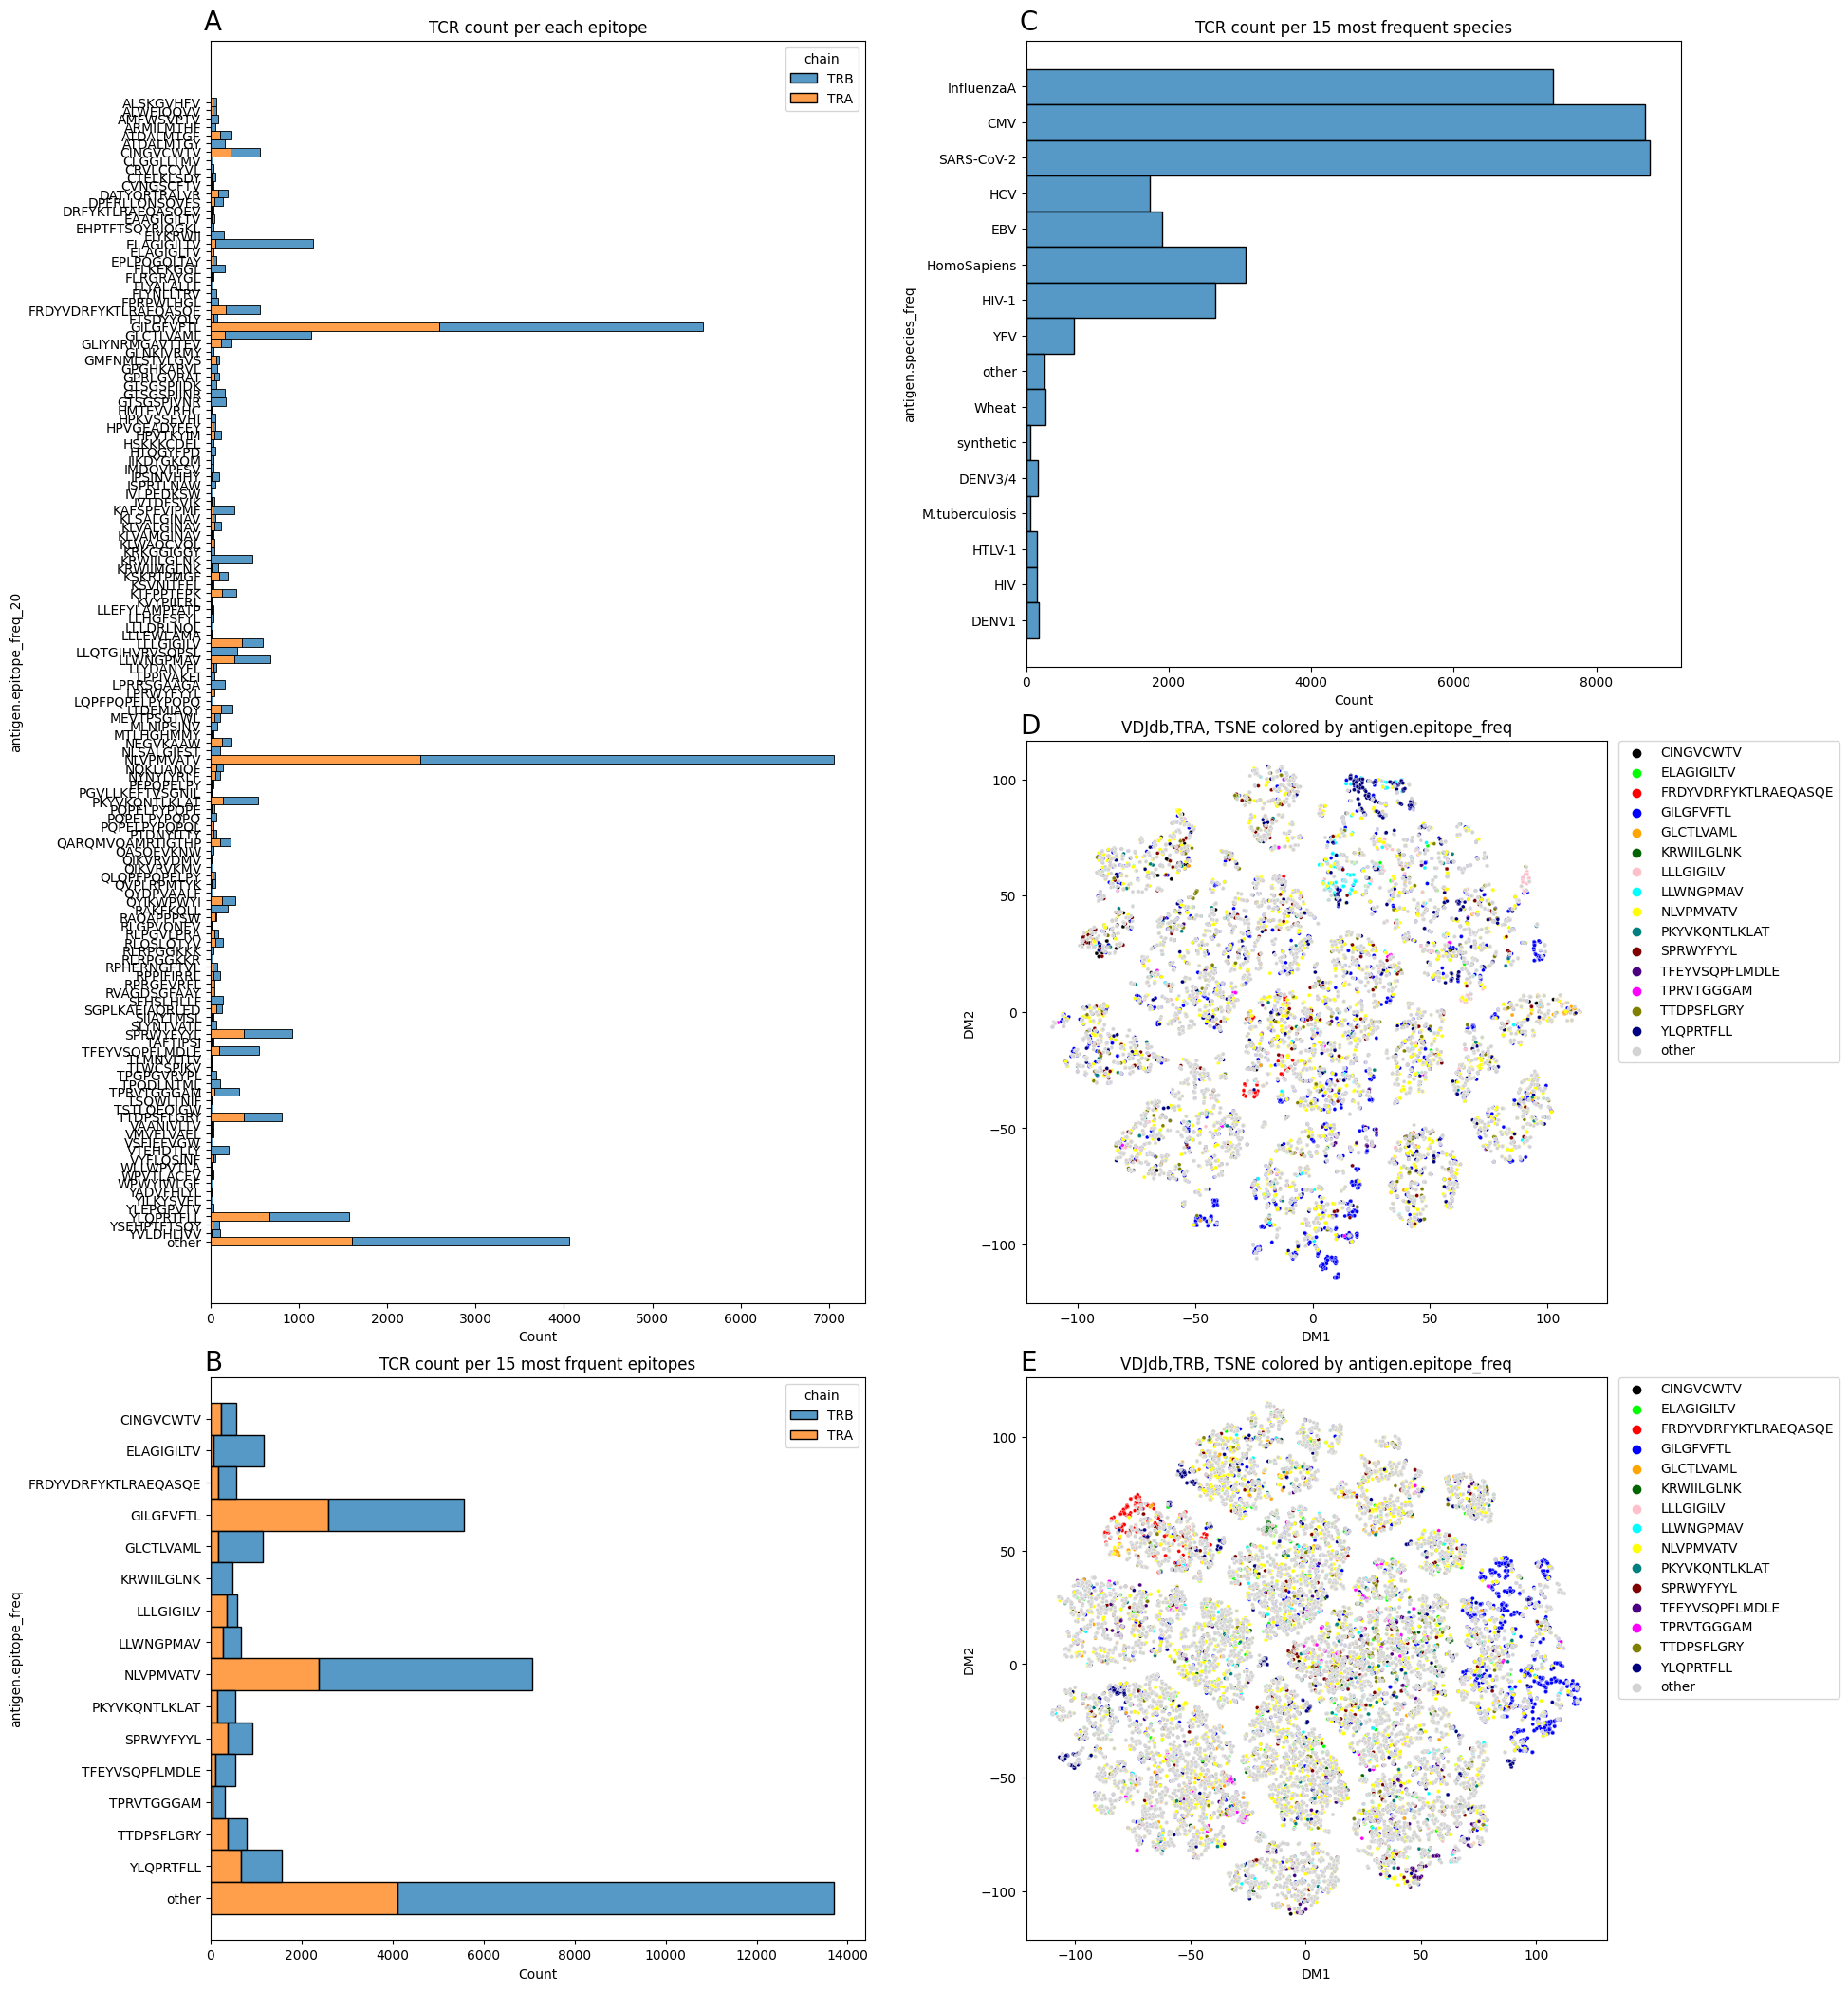

In [24]:

custom_palette = ml_utils.make_custom_palette(label_freq_list)

fig = plt.figure(figsize=(20,26))

delta_x=-0.01
delta_y=1.05
font_size=20


gs00 = fig.add_gridspec(30, 20)

ax1 = fig.add_subplot(gs00[:20, :9])
ax2 = fig.add_subplot(gs00[21:, :9])
ax3 = fig.add_subplot(gs00[:10, 11:])
ax4 = fig.add_subplot(gs00[11:20, 11:19])
ax5 = fig.add_subplot(gs00[21:, 11:19])


sns.histplot(data = data_prebuilt.sort_values(str(label+'_freq_20')), y = str(label+'_freq_20'),hue='chain',multiple='stack', ax=ax1)

ax1.text(delta_x, delta_y - 0.025, 'A',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax1.transAxes,
        size=font_size)
ax1.set_title('TCR count per each epitope')

sns.histplot(data = data_prebuilt.sort_values(str(label+'_freq')), y = str(label+'_freq'),hue='chain',multiple='stack', ax=ax2)

ax2.text(delta_x, delta_y, 'B',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax2.transAxes,
        size=font_size)
ax2.set_title('TCR count per 15 most frquent epitopes')


ax3.text(delta_x, delta_y, 'C',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax3.transAxes,
        size=font_size)
sns.histplot(y=data_prebuilt[label_high_s],ax=ax3)
ax3.set_title('TCR count per 15 most frequent species')

ax4.text(delta_x, delta_y, 'D',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax4.transAxes,
        size=font_size)

chain = 'TRA'
ml_utils.tsne_plot(pd.merge(tcremp.tsne[chain],tcremp.annot[chain]), label_high, f'VDJdb,{chain}, TSNE colored by {label_high}',custom_palette=custom_palette, ax=ax4)
#ax4.set_title('TCR count per 15 most frequent species')

ax5.text(delta_x, delta_y, 'E',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax5.transAxes,
        size=font_size)
chain = 'TRB'
ml_utils.tsne_plot(pd.merge(tcremp.tsne[chain],tcremp.annot[chain]), label_high, f'VDJdb,{chain}, TSNE colored by {label_high}',custom_palette=custom_palette, ax=ax5)
#ax5.set_title('TCR count per 15 most frequent species')


#plt.savefig("results/figures/fig2.png")
plt.show()





## Clustering

### eps by knnn

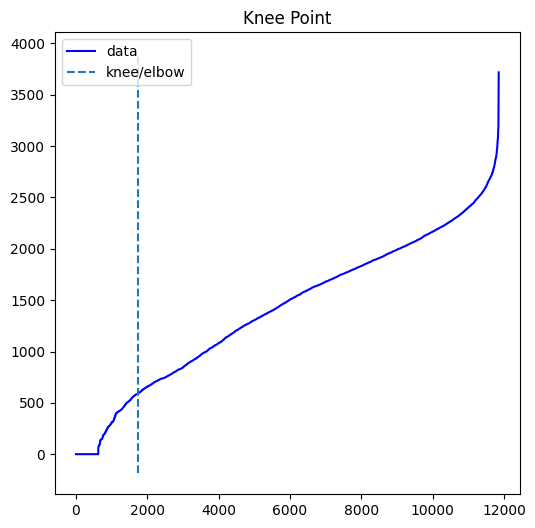

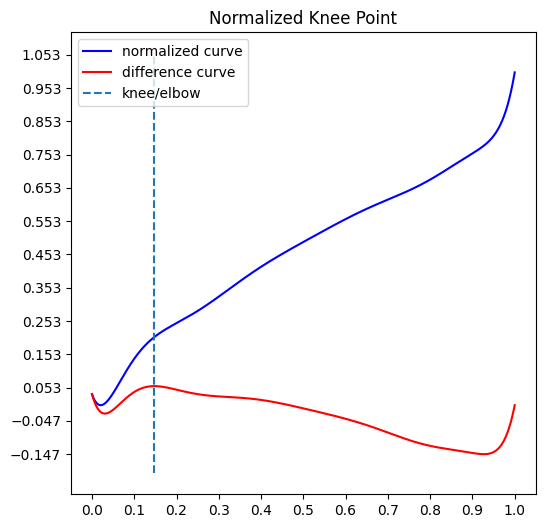

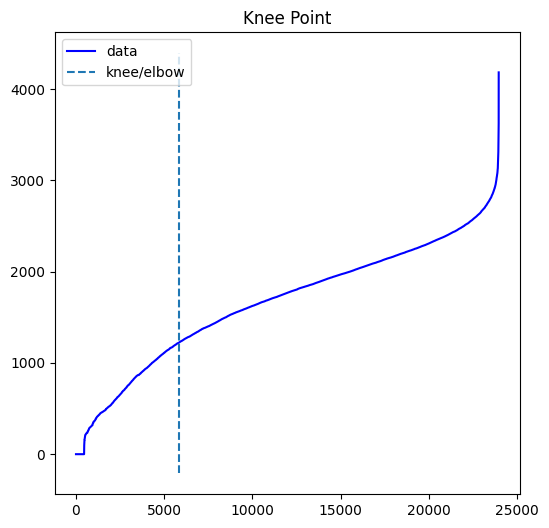

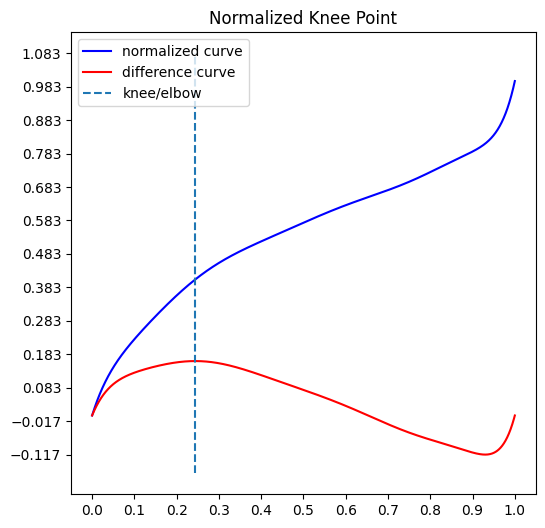

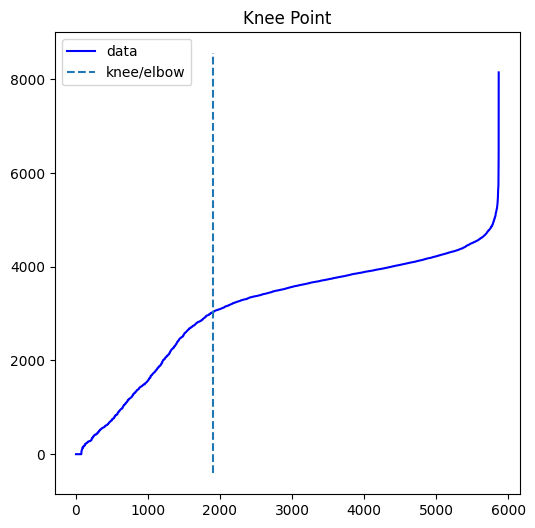

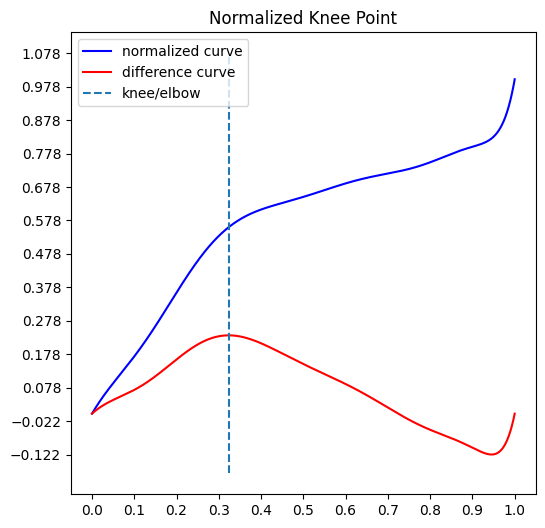

In [15]:
eps_by_knee_dict = {}
for c in ['TRA','TRB','TRA_TRB']:
    chain=c
    eps_by_knee_dict[c]={}
    
    neighbors = 4
#    if chain =='TRA_TRB':
#        nbrs = NearestNeighbors(n_neighbors=neighbors).fit(tcremp.dists[chain]['joined'].drop(tcremp.clonotype_id,axis=1))
#        distances, indices = nbrs.kneighbors(tcremp.dists[chain]['joined'].drop(tcremp.clonotype_id,axis=1))
#    else:
#        nbrs = NearestNeighbors(n_neighbors=neighbors).fit(tcremp.dists[chain].drop(tcremp.clonotype_id,axis=1))
#        distances, indices = nbrs.kneighbors(tcremp.dists[chain].drop(tcremp.clonotype_id,axis=1))
#    distances = np.sort(distances, axis=0)
#    distances = distances[:,1]
    
#    eps_by_knee_dict[c]['max_raw_dist']=round(max(distances),2)
    
    
    nbrs = NearestNeighbors(n_neighbors=neighbors).fit(tcremp.pca_clones[chain].drop(tcremp.clonotype_id,axis=1))
    distances, indices = nbrs.kneighbors(tcremp.pca_clones[chain].drop(tcremp.clonotype_id,axis=1))
    distances = np.sort(distances, axis=0)
    distances = distances[:,1]
    
    eps_by_knee_dict[c]['max_pca_dist']=round(max(distances),2)
    eps_by_knee_dict[c]['clonotypes_count'] = str(len(tcremp.pca_clones[chain]))

    kneedle = KneeLocator(range(1,len(distances)+1),  #x values
                            distances, # y values
                            S=1.0, #parameter suggested from paper
                            #curve="convex", #parameter from figure
                            curve="concave",
                            interp_method="polynomial",
                            #interp_method="polynomial",        
                          polynomial_degree=10,
                            online = True,
                            direction="increasing", ) #parameter from figure
    
    eps_by_knee_dict[c]['knee']=str(round(distances[kneedle.knee],2))
    kneedle.plot_knee()
    kneedle.plot_knee_normalized()

In [15]:
pd.DataFrame(eps_by_knee_dict)

,TRA,TRB,TRA_TRB
max_pca_dist,3739.97,4183.95,8124.9
clonotypes_count,11850,23948,5870
knee,594.26,1225.69,3029.62


### DBSCAN

In [14]:
run_name

'vdjdb_paired'

In [15]:
method= run_name + '_DBSCAN'
dbscan = TCRemP_clstr.TCRemP_clustering('DBSCAN')
metrics_dbscan = {}

In [16]:
metrics_dbscan[label]={}

In [17]:
from sklearn.cluster import DBSCAN

In [53]:
chain='TRA'
#coef = 0.85
#model = DBSCAN(eps=round(float(eps_by_knee_dict[chain]['knee'])*coef,2), min_samples=2)
dbscan.clstr(chain,tcremp, label)

purity:0.8612040133779264


In [54]:
df = tcremp.annot_input[chain].merge(dbscan.clstr_labels[chain], how='left')
df['is_cluster'] = df['is_cluster'].fillna(0)
metrics_dbscan[label][chain] = metrics.get_clustermetrics(df, label)
metrics_dbscan[label][chain]['total pairs TCR-epitope'] = len(tcremp.annot[chain])
metrics_dbscan[label][chain]['total unique TCRs'] = str(len(tcremp.annot[chain].drop_duplicates(tcremp.clonotype_id)))
metrics_dbscan[label][chain]['total unique epitopes'] = str(len(tcremp.annot[chain].drop_duplicates(label)))
metrics_dbscan[label][chain]['label']=label
metrics_dbscan[label][chain]


{'purity': 0.86,
 'retention': 0.12,
 'consistency': 0.0019,
 'ami': 0.78,
 'precision': 0.84,
 'recall': 0.86,
 'f1-score': 0.85,
 'mean_clustsize': 2.74,
 'total pairs TCR-epitope': 10293,
 'total unique TCRs': '10293',
 'total unique epitopes': '740',
 'label': 'antigen.epitope'}

In [56]:
l

2                 ELAGIGILTV
53                KRWIILGLNK
90             PKYVKQNTLKLAT
92                 GILGFVFTL
102                NLVPMVATV
104                GLCTLVAML
179                YLQPRTFLL
192                LLLGIGILV
509                 NEGVKAAW
859                LLWNGPMAV
4451               CINGVCWTV
5461          TFEYVSQPFLMDLE
5511    FRDYVDRFYKTLRAEQASQE
6628              TTDPSFLGRY
7681               SPRWYFYYL
Name: antigen.epitope_freq, dtype: object

In [58]:
l = df[df[label_high]!='other'][label_high].drop_duplicates()
d={}
for e in l:
    print(len(df[df[label]==e]))
    if len(df[df[label]==e])>10:
        d[e]=metrics.get_clustermetrics(df[df[label]==e], label)
pd.DataFrame(d)


56
4
106
2405
2097
155
584
314
122
246
186
93
153
280
352


,ELAGIGILTV,PKYVKQNTLKLAT,GILGFVFTL,NLVPMVATV,GLCTLVAML,YLQPRTFLL,LLLGIGILV,NEGVKAAW,LLWNGPMAV,CINGVCWTV,TFEYVSQPFLMDLE,FRDYVDRFYKTLRAEQASQE,TTDPSFLGRY,SPRWYFYYL
purity,0.5900,0.50,0.8400,0.7200,0.9500,0.840,0.6100,0.5700,0.680,0.6900,0.9000,0.9600,0.7400,0.5800
retention,0.1600,0.05,0.1500,0.0700,0.2100,0.270,0.1500,0.1100,0.160,0.0500,0.4900,0.4600,0.0700,0.0500
consistency,0.3333,0.20,0.0279,0.0612,0.1875,0.057,0.0833,0.2143,0.125,0.3333,0.3696,0.2817,0.2632,0.1176
ami,0.0000,0.00,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.000,0.0000,1.0000,0.0000,0.0000,0.0000
precision,1.0000,1.00,1.0000,1.0000,1.0000,1.000,1.0000,1.0000,1.000,1.0000,1.0000,1.0000,1.0000,1.0000
recall,0.4400,0.80,0.9300,0.8000,0.9400,0.960,0.8500,0.7900,0.750,0.8900,1.0000,0.9900,0.6800,0.8200
f1-score,0.6200,0.89,0.9600,0.8900,0.9700,0.980,0.9200,0.8800,0.860,0.9400,1.0000,0.9900,0.8100,0.9000
mean_clustsize,2.8300,2.00,2.8100,2.6800,2.8500,3.030,3.1900,3.7500,3.150,2.1700,4.2500,4.1700,2.4500,2.3800


In [21]:
dbscan.clstr_metrics_calc(chain, tcremp)
dbscan.clstr_metrics[chain]

{'purity': 0.86,
 'retention': 0.12,
 'consistency': 0.0019,
 'ami': 0.78,
 'precision': 0.84,
 'recall': 0.86,
 'f1-score': 0.85,
 'mean_clustsize': 2.74,
 'total pairs TCR-epitope': 10293,
 'total unique TCRs': '10293',
 'total unique epitopes': '740',
 'label': 'antigen.epitope'}

In [ ]:
df = tcremp.annot_input[chain].merge(dbscan.clstr_labels[chain], how='left')
df['is_cluster'] = df['is_cluster'].fillna(0)
metrics_dbscan[label][chain] = metrics.get_clustermetrics(df, label)
metrics_dbscan[label][chain]['total pairs TCR-epitope'] = len(tcremp.annot[chain])
metrics_dbscan[label][chain]['total unique TCRs'] = str(len(tcremp.annot[chain].drop_duplicates(tcremp.clonotype_id)))
metrics_dbscan[label][chain]['total unique epitopes'] = str(len(tcremp.annot[chain].drop_duplicates(label)))
metrics_dbscan[label][chain]['label']=label
metrics_dbscan[label][chain]


In [59]:
chain='TRB'
#model = DBSCAN(eps=round(float(eps_by_knee_dict[chain]['knee'])*coef,2), min_samples=2)
dbscan.clstr(chain,tcremp, label)

purity:0.8837389953392025


In [60]:
df = tcremp.annot_input[chain].merge(dbscan.clstr_labels[chain], how='left')
df['is_cluster'] = df['is_cluster'].fillna(0)
metrics_dbscan[label][chain] = metrics.get_clustermetrics(df, label)
metrics_dbscan[label][chain]['total pairs TCR-epitope'] = len(tcremp.annot[chain])
metrics_dbscan[label][chain]['total unique TCRs'] = str(len(tcremp.annot[chain].drop_duplicates(tcremp.clonotype_id)))
metrics_dbscan[label][chain]['total unique epitopes'] = str(len(tcremp.annot[chain].drop_duplicates(label)))
metrics_dbscan[label][chain]['label']=label
metrics_dbscan[label][chain]


{'purity': 0.88,
 'retention': 0.16,
 'consistency': 0.0009,
 'ami': 0.83,
 'precision': 0.87,
 'recall': 0.88,
 'f1-score': 0.88,
 'mean_clustsize': 3.37,
 'total pairs TCR-epitope': 23948,
 'total unique TCRs': '23948',
 'total unique epitopes': '999',
 'label': 'antigen.epitope'}

In [61]:
l = df[df[label_high]!='other'][label_high].drop_duplicates()
d={}
for e in l:
    print(len(df[df[label]==e]))
    if len(df[df[label]==e])>10:
        d[e]=metrics.get_clustermetrics(df[df[label]==e], label)
pd.DataFrame(d)


1106
468
4738
388
3008
974
937
409
234
118
338
452
386
421
540


,ELAGIGILTV,KRWIILGLNK,NLVPMVATV,PKYVKQNTLKLAT,GILGFVFTL,GLCTLVAML,YLQPRTFLL,LLWNGPMAV,LLLGIGILV,NEGVKAAW,CINGVCWTV,TFEYVSQPFLMDLE,FRDYVDRFYKTLRAEQASQE,TTDPSFLGRY,SPRWYFYYL
purity,0.7100,0.8800,0.810,0.6900,0.8900,0.8300,0.9200,0.9200,0.730,0.7100,0.7600,0.8700,0.9600,0.6700,0.6900
retention,0.0600,0.2600,0.100,0.0600,0.3200,0.2100,0.4100,0.0800,0.070,0.3000,0.0700,0.0900,0.4200,0.0700,0.0600
consistency,0.0588,0.1066,0.037,0.1667,0.1207,0.0693,0.0914,0.0938,0.125,0.2857,0.0833,0.0769,0.1863,0.0667,0.0938
ami,0.0000,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
precision,1.0000,1.0000,1.000,1.0000,1.0000,1.0000,1.0000,1.0000,1.000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
recall,0.6000,0.9500,0.800,0.8300,0.9800,0.9400,0.9700,0.8400,0.690,0.6000,0.8800,0.8700,1.0000,0.8700,0.7800
f1-score,0.7500,0.9700,0.890,0.9100,0.9900,0.9700,0.9900,0.9200,0.810,0.7500,0.9300,0.9300,1.0000,0.9300,0.8800
mean_clustsize,3.4600,2.9400,3.740,2.4400,5.5400,3.3700,4.4400,7.8600,2.730,5.0800,2.3800,3.0000,3.2300,2.4000,2.2900


In [62]:
chain='TRA_TRB'

dbscan.clstr(chain,tcremp, label)

purity:0.9630238290879212


In [63]:
df = tcremp.annot_input[chain].merge(dbscan.clstr_labels[chain], how='left')
df['is_cluster'] = df['is_cluster'].fillna(0)
metrics_dbscan[label][chain] = metrics.get_clustermetrics(df, label)
metrics_dbscan[label][chain]['total pairs TCR-epitope'] = len(tcremp.annot[chain])
metrics_dbscan[label][chain]['total unique TCRs'] = str(len(tcremp.annot[chain].drop_duplicates(tcremp.clonotype_id)))
metrics_dbscan[label][chain]['total unique epitopes'] = str(len(tcremp.annot[chain].drop_duplicates(label)))
metrics_dbscan[label][chain]['label']=label
metrics_dbscan[label][chain]

{'purity': 0.96,
 'retention': 0.28,
 'consistency': 0.0065,
 'ami': 0.94,
 'precision': 0.96,
 'recall': 0.96,
 'f1-score': 0.96,
 'mean_clustsize': 5.27,
 'total pairs TCR-epitope': 4405,
 'total unique TCRs': '4405',
 'total unique epitopes': '610',
 'label': 'antigen.epitope'}

In [64]:
l = df[df[label_high]!='other'][label_high].drop_duplicates()
d={}
for e in l:
    print(len(df[df[label]==e]))
    d[e]=metrics.get_clustermetrics(df[df[label]==e], label)
pd.DataFrame(d)


48
39
511
134
260
179
182
164
353
221
248


,ELAGIGILTV,PKYVKQNTLKLAT,GILGFVFTL,GLCTLVAML,NLVPMVATV,YLQPRTFLL,LLWNGPMAV,CINGVCWTV,TFEYVSQPFLMDLE,TTDPSFLGRY,SPRWYFYYL
purity,1.0000,0.50,0.970,0.9400,0.9400,0.9600,0.9700,0.9000,0.9900,1.0000,0.9000
retention,0.1200,0.03,0.610,0.5800,0.2900,0.2000,0.3200,0.1200,0.8300,0.1400,0.0700
consistency,0.3333,1.00,0.375,0.3205,0.1733,0.5143,0.0862,0.1053,0.5856,0.3438,0.1111
ami,1.0000,1.00,0.000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000
precision,1.0000,1.00,1.000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
recall,1.0000,1.00,0.990,1.0000,0.9200,0.8000,0.9700,0.7400,1.0000,1.0000,1.0000
f1-score,1.0000,1.00,0.990,1.0000,0.9600,0.8900,0.9800,0.8500,1.0000,1.0000,1.0000
mean_clustsize,2.0000,2.00,9.580,4.8800,10.3600,22.5000,4.5000,4.2500,16.4700,3.2000,2.0000


In [ ]:
GILGFVFTL
TFEYVSQPFLMDLE

In [52]:
pd.DataFrame(d)


,ELAGIGILTV,PKYVKQNTLKLAT,GILGFVFTL,GLCTLVAML,NLVPMVATV,YLQPRTFLL,LLWNGPMAV,CINGVCWTV,TFEYVSQPFLMDLE,TTDPSFLGRY,SPRWYFYYL
purity,1.0000,0.50,0.970,0.9400,0.9400,0.9600,0.9700,0.9000,0.9900,1.0000,0.9000
retention,0.1200,0.03,0.610,0.5800,0.2900,0.2000,0.3200,0.1200,0.8300,0.1400,0.0700
consistency,0.3333,1.00,0.375,0.3205,0.1733,0.5143,0.0862,0.1053,0.5856,0.3438,0.1111
ami,1.0000,1.00,0.000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000
precision,1.0000,1.00,1.000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
recall,1.0000,1.00,0.990,1.0000,0.9200,0.8000,0.9700,0.7400,1.0000,1.0000,1.0000
f1-score,1.0000,1.00,0.990,1.0000,0.9600,0.8900,0.9800,0.8500,1.0000,1.0000,1.0000
mean_clustsize,2.0000,2.00,9.580,4.8800,10.3600,22.5000,4.5000,4.2500,16.4700,3.2000,2.0000


In [32]:
pd.DataFrame(metrics_dbscan[label])

,TRA,TRB,TRA_TRB
purity,0.86,0.88,0.96
retention,0.12,0.16,0.28
consistency,0.0019,0.0009,0.0065
ami,0.78,0.83,0.94
precision,0.84,0.87,0.96
recall,0.86,0.88,0.96
f1-score,0.85,0.88,0.96
mean_clustsize,2.74,3.37,5.27
total pairs TCR-epitope,10293,23948,4405
total unique TCRs,10293,23948,4405


In [27]:
pd.DataFrame(metrics_dbscan[label])

,TRA,TRB,TRA_TRB
purity,0.85,0.89,0.95
retention,0.11,0.16,0.26
consistency,0.0016,0.0009,0.0053
ami,0.76,0.83,0.93
precision,0.83,0.88,0.95
recall,0.85,0.89,0.95
f1-score,0.84,0.88,0.95
mean_clustsize,2.69,3.36,5.2
total pairs TCR-epitope,11850,23948,5870
total unique TCRs,11850,23948,5870


In [28]:
pd.DataFrame(metrics_dbscan[label]).to_csv(f"results/tables/{method}.csv",index=False)

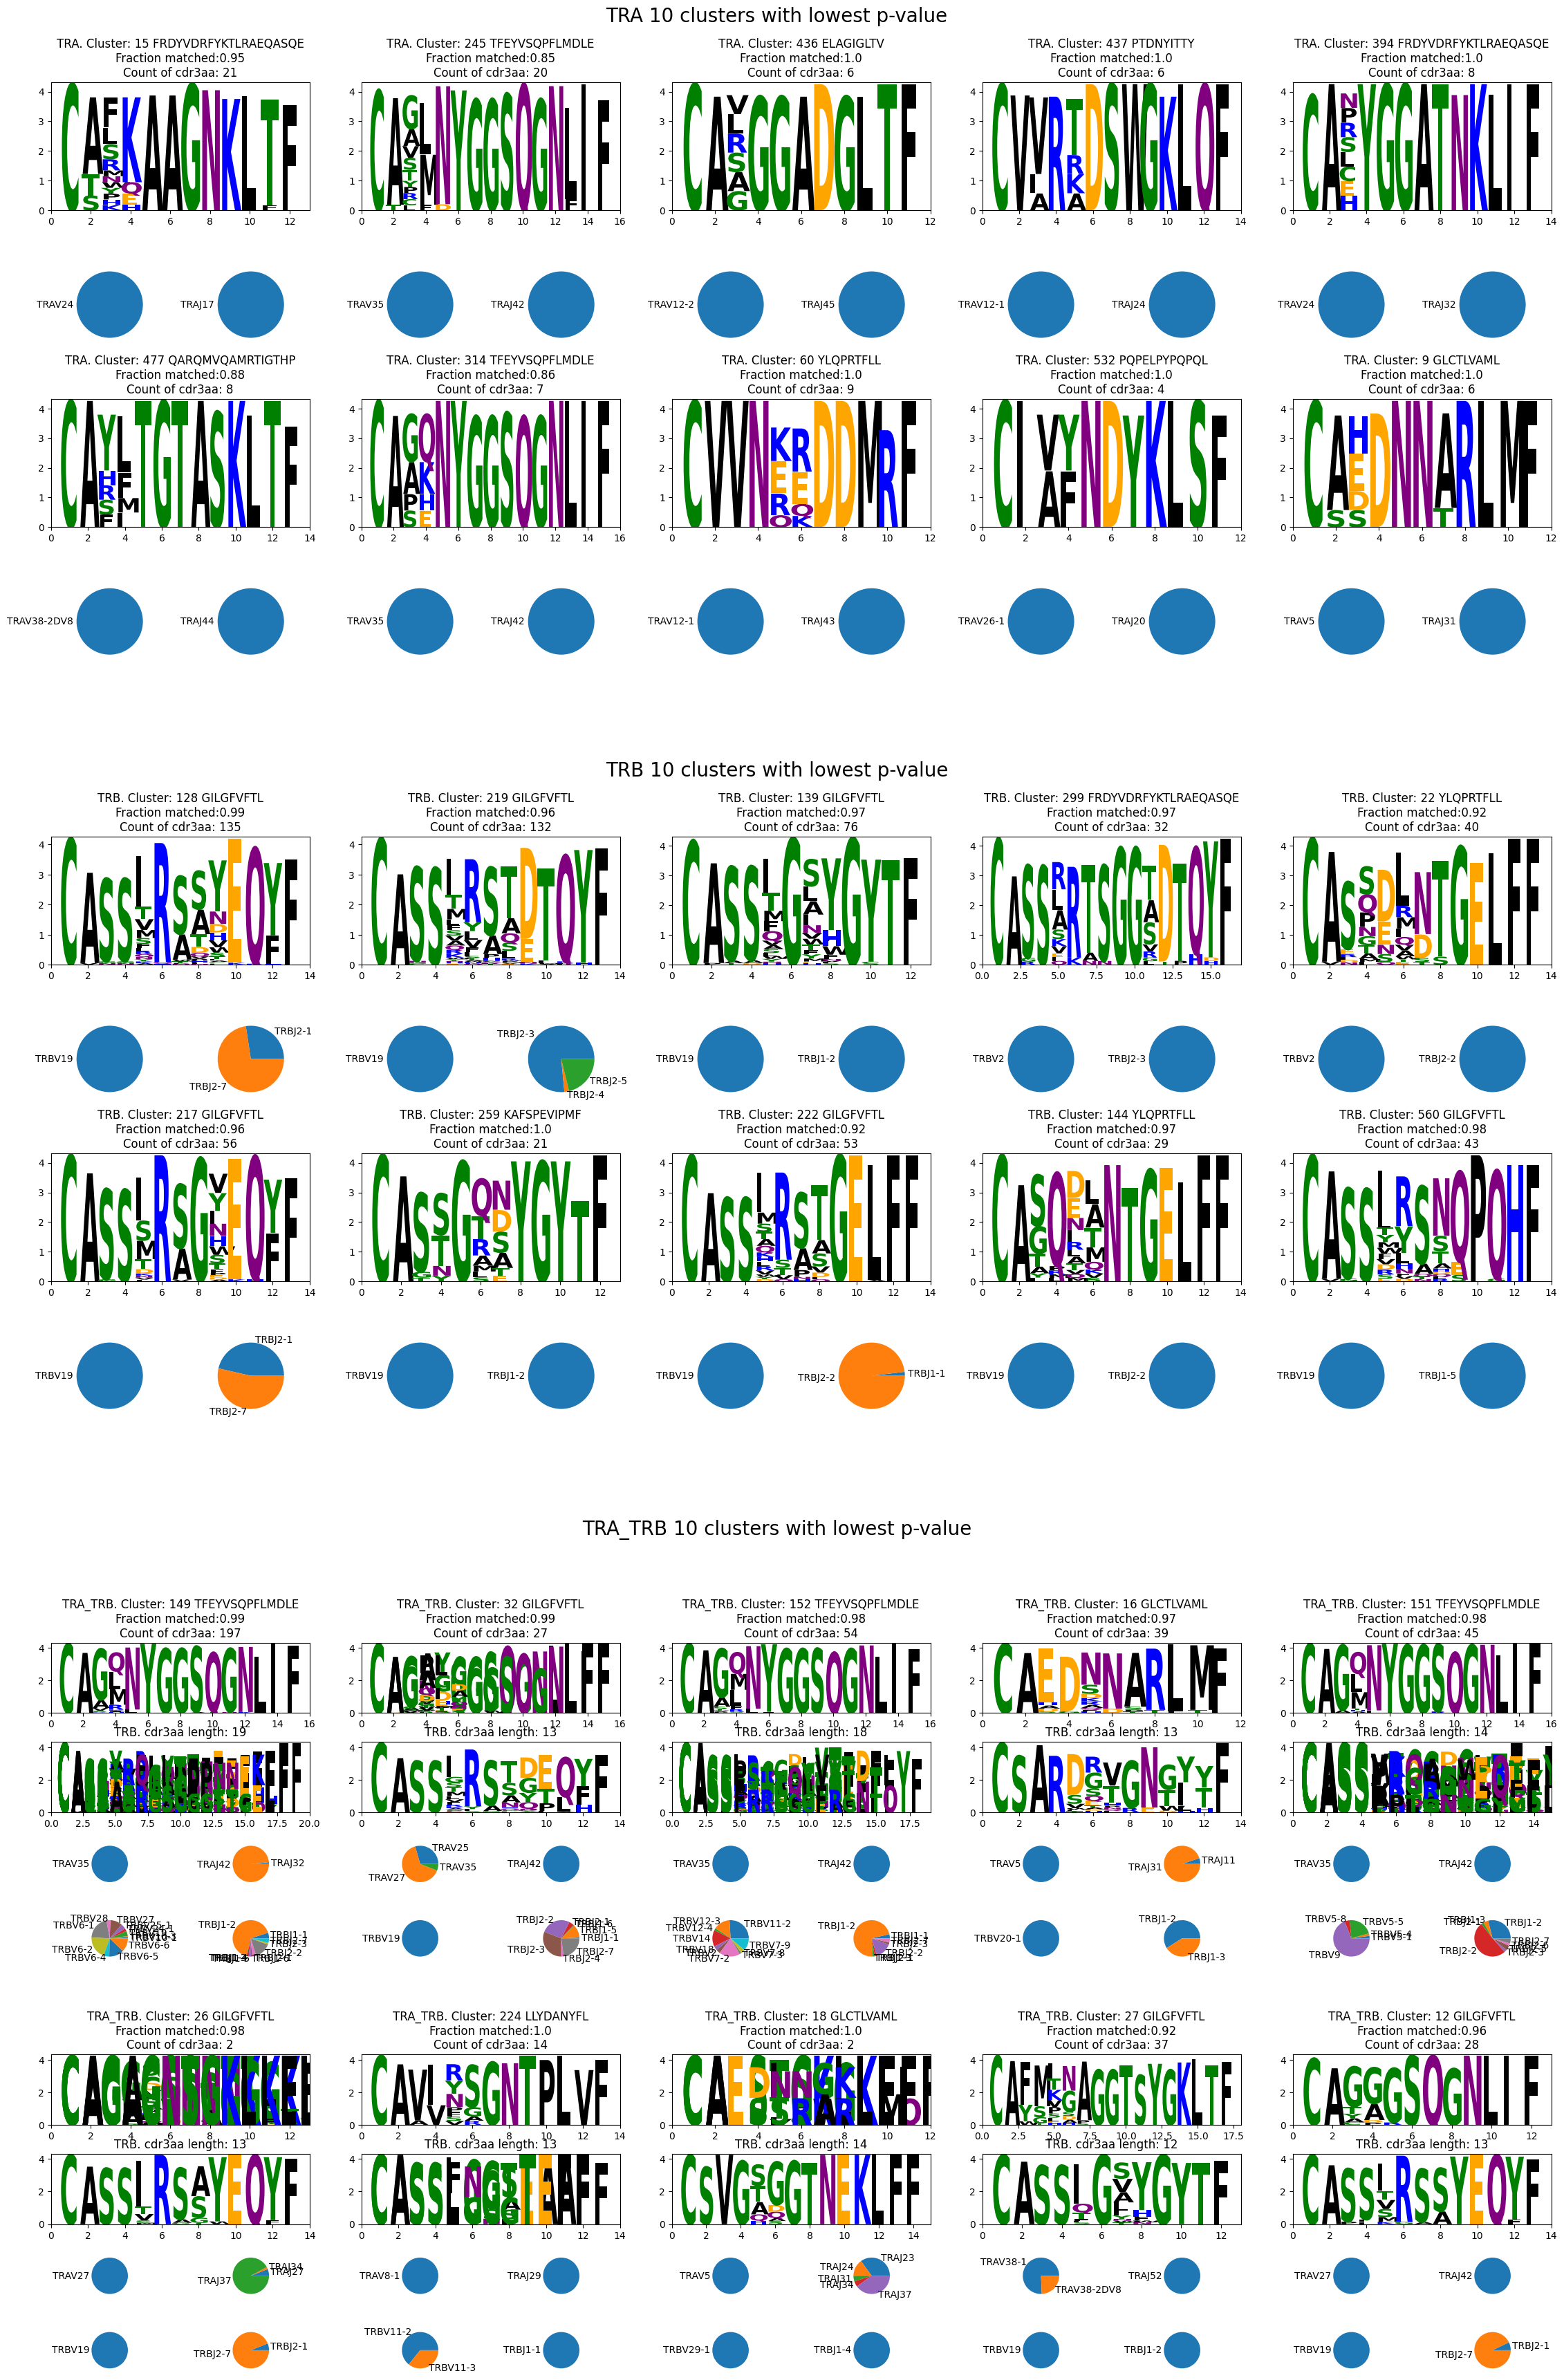

In [38]:
fig = plt.figure(figsize=(28,6*6))
subfigs = fig.subfigures(3, 1,height_ratios=[1,1,1.3])
dbscan.clstrs_motif(tcremp,'TRA', 10, subfigs[0])
subfigs[0].suptitle('TRA 10 clusters with lowest p-value',fontsize=20)
dbscan.clstrs_motif(tcremp, 'TRB', 10, subfigs[1])
subfigs[1].suptitle('TRB 10 clusters with lowest p-value',fontsize=20)
dbscan.clstrs_motif(tcremp, 'TRA_TRB', 10, subfigs[2])
subfigs[2].suptitle('TRA_TRB 10 clusters with lowest p-value',fontsize=20)
#plt.savefig(f"results/figures/vdjdb_dbscan_logo.png",bbox_inches='tight')

if unique_clonotypes:
    plt.savefig(f"results/figures/vdjdb_dbscan_logo_unique_clonotypes.png",bbox_inches='tight')
else:
    plt.savefig(f"results/figures/vdjdb_dbscan_logo.png",bbox_inches='tight')
plt.show()

In [44]:
dbscan.clstr_labels['TRA_TRB'][dbscan.clstr_labels['TRA_TRB']['cluster']==26].drop_duplicates('a_cdr3aa')

,cluster,annotId,label_cluster,total_cluster,total_group,count_matched,fraction_matched,fraction_matched_exp,p_value,is_cluster,enriched_clstr,a_cdr3aa,TRAV,TRAJ,b_cdr3aa,TRBV,TRBJ
136,26,136,GILGFVFTL,50,663,49,0.98,0.112947,1.733485e-45,1,1,CAGAIGPSNTGKLIF,TRAV27,TRAJ37,CASSIRSSYEQYF,TRBV19,TRBJ2-7
180,26,180,GILGFVFTL,50,663,49,0.98,0.112947,1.733485e-45,1,1,CAGATGNTGKLIF,TRAV27,TRAJ37,CASSTRGAYEQYF,TRBV19,TRBJ2-7
456,26,456,GILGFVFTL,50,663,49,0.98,0.112947,1.733485e-45,1,1,CAGPGTNAGKSTF,TRAV27,TRAJ27,CASSTRSSYEQYF,TRBV19,TRBJ2-7
595,26,595,GILGFVFTL,50,663,49,0.98,0.112947,1.733485e-45,1,1,CAGAFGSSNTGKLIF,TRAV27,TRAJ37,CASSIRSAYEQYF,TRBV19,TRBJ2-7
600,26,600,GILGFVFTL,50,663,49,0.98,0.112947,1.733485e-45,1,1,CAGADGSSNTGKLIF,TRAV27,TRAJ37,CASSTRSAYEQYF,TRBV19,TRBJ2-7
611,26,611,GILGFVFTL,50,663,49,0.98,0.112947,1.733485e-45,1,1,CAGAIGSSNTGKLIF,TRAV27,TRAJ37,CASSIRSSYEQYF,TRBV19,TRBJ2-7
722,26,722,GILGFVFTL,50,663,49,0.98,0.112947,1.733485e-45,1,1,CAGALGSSNTGKLIF,TRAV27,TRAJ37,CASSIRSAYEQFF,TRBV19,TRBJ2-1
725,26,725,GILGFVFTL,50,663,49,0.98,0.112947,1.733485e-45,1,1,CAGADSSSNTGKLIF,TRAV27,TRAJ37,CASSIRSAYEQYF,TRBV19,TRBJ2-7
727,26,727,GILGFVFTL,50,663,49,0.98,0.112947,1.733485e-45,1,1,CAGARGSSNTGKLIF,TRAV27,TRAJ37,CASSIRSAYEQYF,TRBV19,TRBJ2-7
728,26,728,GILGFVFTL,50,663,49,0.98,0.112947,1.733485e-45,1,1,CAGASGSGNTGKLIF,TRAV27,TRAJ37,CASSIRSAYEQYF,TRBV19,TRBJ2-7


In [93]:
dbscan_s = tcremp.tcremp_clustering('DBSCAN')

In [94]:
metrics_dbscan[label_s]={}

In [95]:
chain='TRA'
model = DBSCAN(eps=750, min_samples=2)
dbscan_s.clstr(chain,tcremp, label_s, model=model)

purity:0.8828107118333715


In [96]:
df = tcremp.annot[chain].merge(dbscan_s.clstr_labels[chain])
metrics_dbscan[label_s][chain] = metrics.get_clustermetrics(df, label_s)
metrics_dbscan[label_s][chain]['total pairs TCR-specie'] = len(tcremp.annot[chain])
metrics_dbscan[label_s][chain]['total unique TCRs'] = str(len(tcremp.annot[chain].drop_duplicates(tcremp.clonotype_id)))
metrics_dbscan[label_s][chain]['total unique antigen species'] = str(len(tcremp.annot[chain].drop_duplicates(label_s)))
metrics_dbscan[label_s][chain]['label']=label_s
metrics_dbscan[label_s][chain]

{'purity': 0.8828107118333715,
 'retention': 0.2966,
 'consistency': 0.01,
 'ami': 0.6997,
 'precision': 0.8826,
 'recall': 0.8828,
 'f1-score': 0.8827,
 'mean_clustsize': 5.3607,
 'total pairs TCR-specie': 14730,
 'total unique TCRs': '11850',
 'total unique antigen species': '27',
 'label': 'antigen.species'}

In [97]:
chain='TRB'
model = DBSCAN(eps=750, min_samples=2)
dbscan_s.clstr(chain,tcremp, label_s, model=model)

purity:0.9461856889414547


In [98]:
df = tcremp.annot[chain].merge(dbscan_s.clstr_labels[chain])
metrics_dbscan[label_s][chain] = metrics.get_clustermetrics(df, label_s)
metrics_dbscan[label_s][chain]['total pairs TCR-specie'] = len(tcremp.annot[chain])
metrics_dbscan[label_s][chain]['total unique TCRs'] = str(len(tcremp.annot[chain].drop_duplicates(tcremp.clonotype_id)))
metrics_dbscan[label_s][chain]['total unique antigen species'] = str(len(tcremp.annot[chain].drop_duplicates(label_s)))
metrics_dbscan[label_s][chain]['label']=label_s
metrics_dbscan[label_s][chain]

{'purity': 0.9461856889414547,
 'retention': 0.1737,
 'consistency': 0.0075,
 'ami': 0.856,
 'precision': 0.9455,
 'recall': 0.9462,
 'f1-score': 0.9458,
 'mean_clustsize': 5.4026,
 'total pairs TCR-specie': 29207,
 'total unique TCRs': '23948',
 'total unique antigen species': '30',
 'label': 'antigen.species'}

In [99]:
chain='TRA_TRB'
model = DBSCAN(eps=750, min_samples=2)
dbscan_s.clstr(chain,tcremp, label_s, model=model)

purity:0.988388969521045


In [100]:
df = tcremp.annot[chain].merge(dbscan_s.clstr_labels[chain])
metrics_dbscan[label_s][chain] = metrics.get_clustermetrics(df, label_s)
metrics_dbscan[label_s][chain]['total pairs TCR-specie'] = len(tcremp.annot[chain])
metrics_dbscan[label_s][chain]['total unique TCRs'] = str(len(tcremp.annot[chain].drop_duplicates(tcremp.clonotype_id)))
metrics_dbscan[label_s][chain]['total unique antigen species'] = str(len(tcremp.annot[chain].drop_duplicates(label_s)))
metrics_dbscan[label_s][chain]['label']=label_s
metrics_dbscan[label_s][chain]

{'purity': 0.988388969521045,
 'retention': 0.1062,
 'consistency': 0.0154,
 'ami': 0.9647,
 'precision': 0.9857,
 'recall': 0.9884,
 'f1-score': 0.987,
 'mean_clustsize': 4.0769,
 'total pairs TCR-specie': 6490,
 'total unique TCRs': '5870',
 'total unique antigen species': '26',
 'label': 'antigen.species'}

In [85]:
pd.DataFrame(metrics_dbscan[label_s])

,TRA,TRB,TRA_TRB
purity,0.882811,0.946186,0.988389
retention,0.2966,0.1737,0.1062
consistency,0.0012,0.0015,0.0073
ami,0.5498,0.6619,0.8194
precision,0.0,0.0,0.0
recall,0.0,0.0,0.0
f1-score,0,0,0
mean_clustsize,5.3607,5.4026,4.0769
total pairs TCR-epitope,14730,29207,6490
total unique TCRs,11850,23948,5870


In [101]:
pd.concat([pd.DataFrame(metrics_dbscan[label]),pd.DataFrame(metrics_dbscan[label_s])],axis=1)

,TRA,TRB,TRA_TRB,TRA,TRB,TRA_TRB
purity,0.843214,0.928839,0.985486,0.882811,0.946186,0.988389
retention,0.2966,0.1737,0.1062,0.2966,0.1737,0.1062
consistency,0.0012,0.0015,0.0073,0.01,0.0075,0.0154
ami,0.7564,0.8912,0.9702,0.6997,0.856,0.9647
precision,0.818,0.9236,0.9825,0.8826,0.9455,0.9857
recall,0.8432,0.9288,0.9855,0.8828,0.9462,0.9884
f1-score,0.8304,0.9262,0.984,0.8827,0.9458,0.987
mean_clustsize,5.3607,5.4026,4.0769,5.3607,5.4026,4.0769
total pairs TCR-epitope,14730,29207,6490,NaN,NaN,NaN
total unique TCRs,11850,23948,5870,11850,23948,5870


In [ ]:
metrcs_res = pd.DataFrame(metrics_dbscan)
metrcs_res

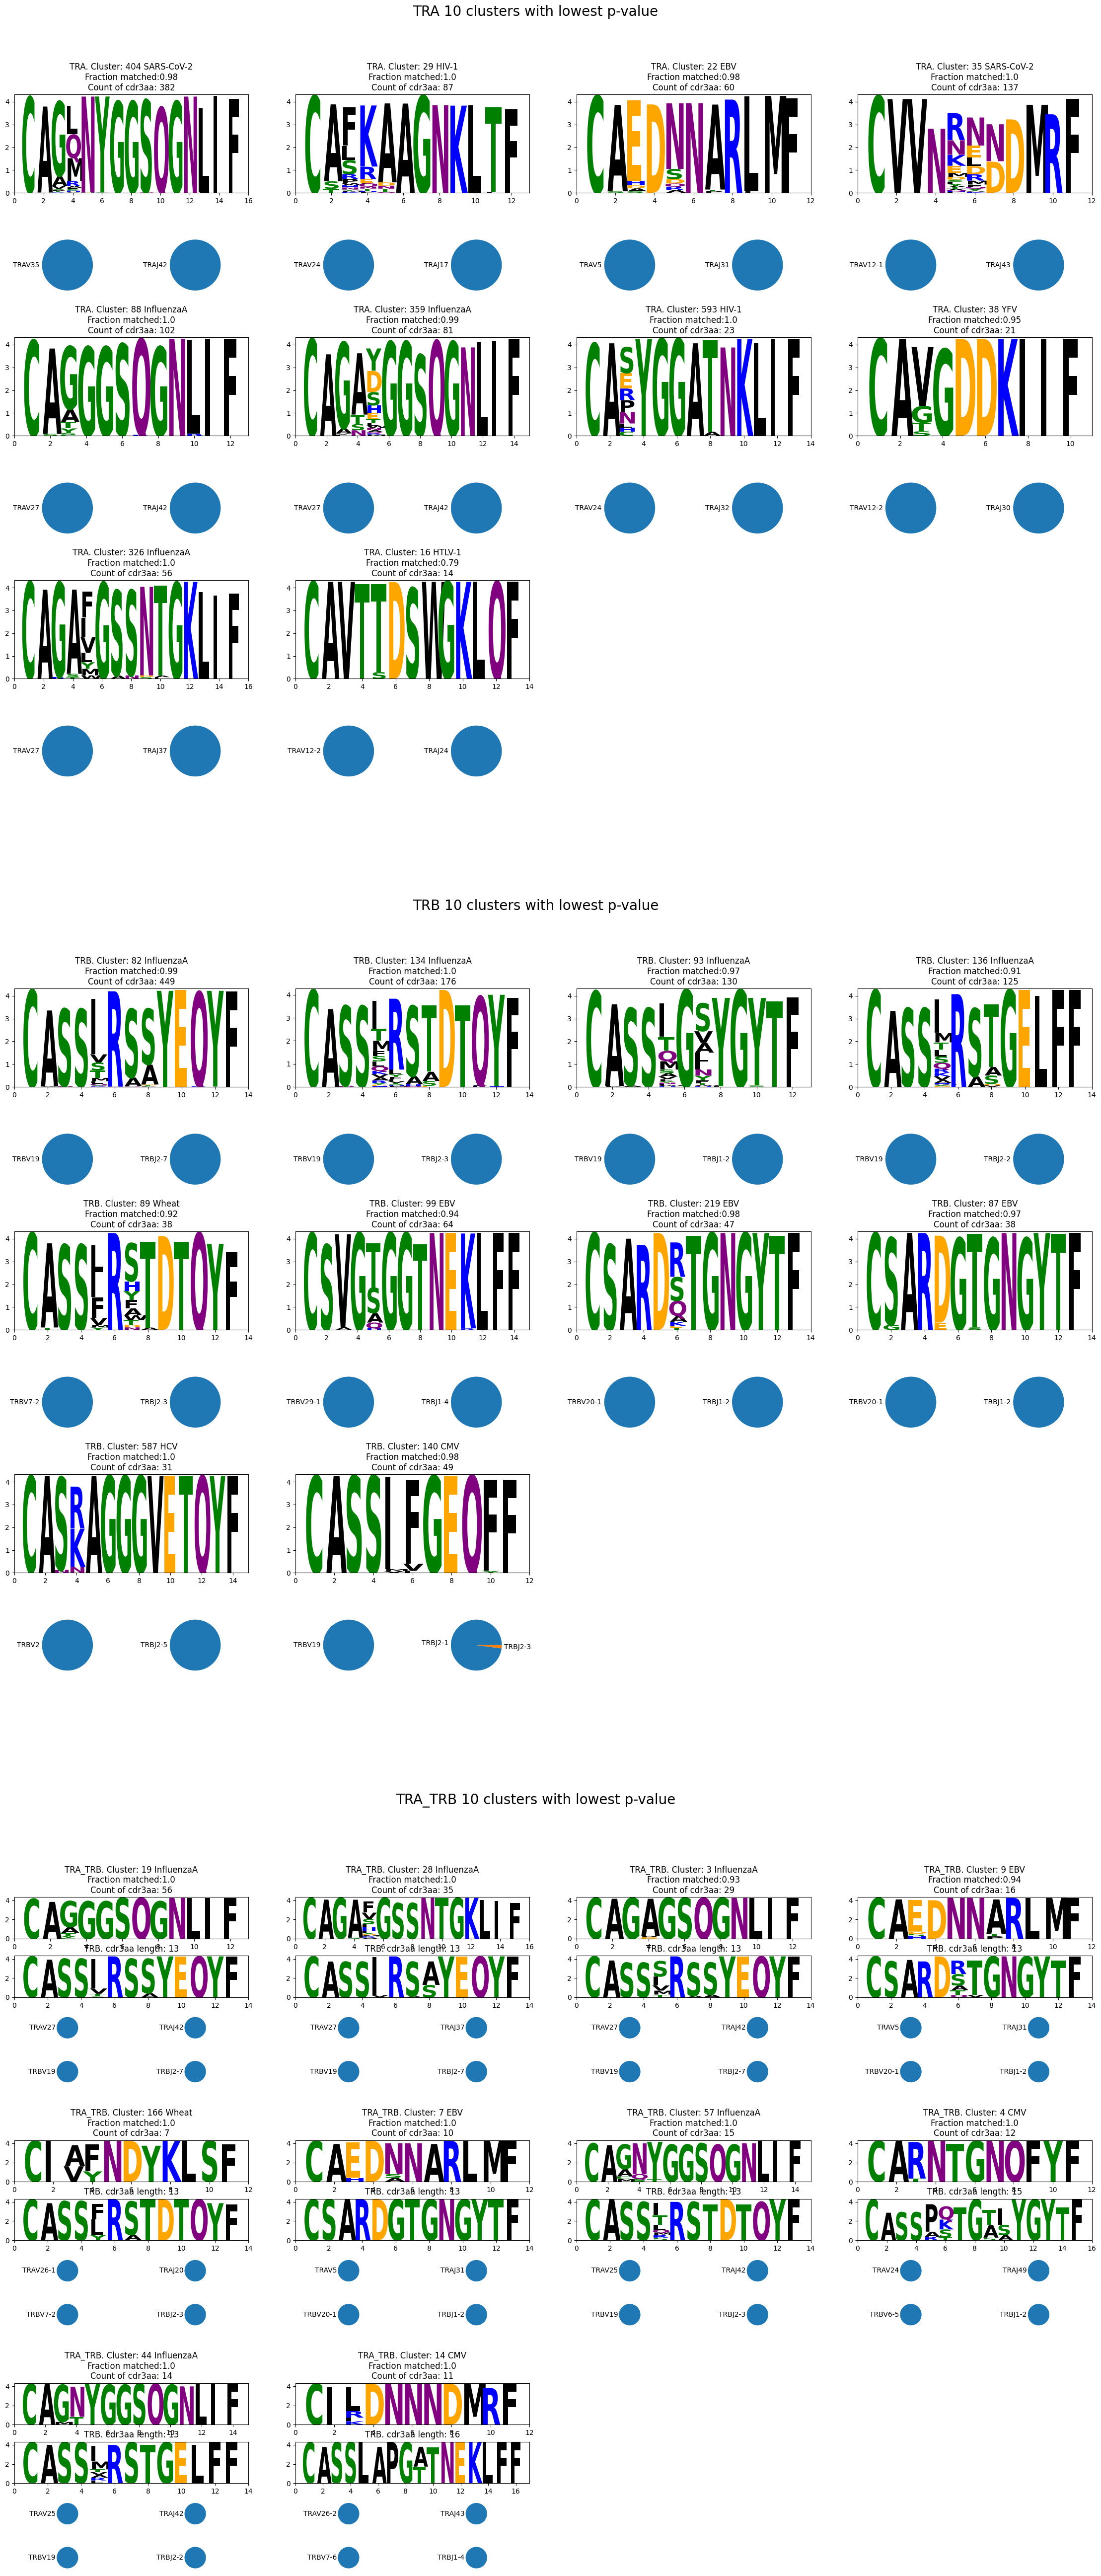

In [102]:
fig = plt.figure(figsize=(28,6*9))
subfigs = fig.subfigures(3, 1)
dbscan_s.clstrs_motif(tcremp,'TRA', 10, subfigs[0])
subfigs[0].suptitle('TRA 10 clusters with lowest p-value',fontsize=20)
dbscan_s.clstrs_motif(tcremp, 'TRB', 10, subfigs[1])
subfigs[1].suptitle('TRB 10 clusters with lowest p-value',fontsize=20)
dbscan_s.clstrs_motif(tcremp, 'TRA_TRB', 10, subfigs[2])
subfigs[2].suptitle('TRA_TRB 10 clusters with lowest p-value',fontsize=20)
plt.savefig(f"results/figures/fig3_dbscan_s.png")

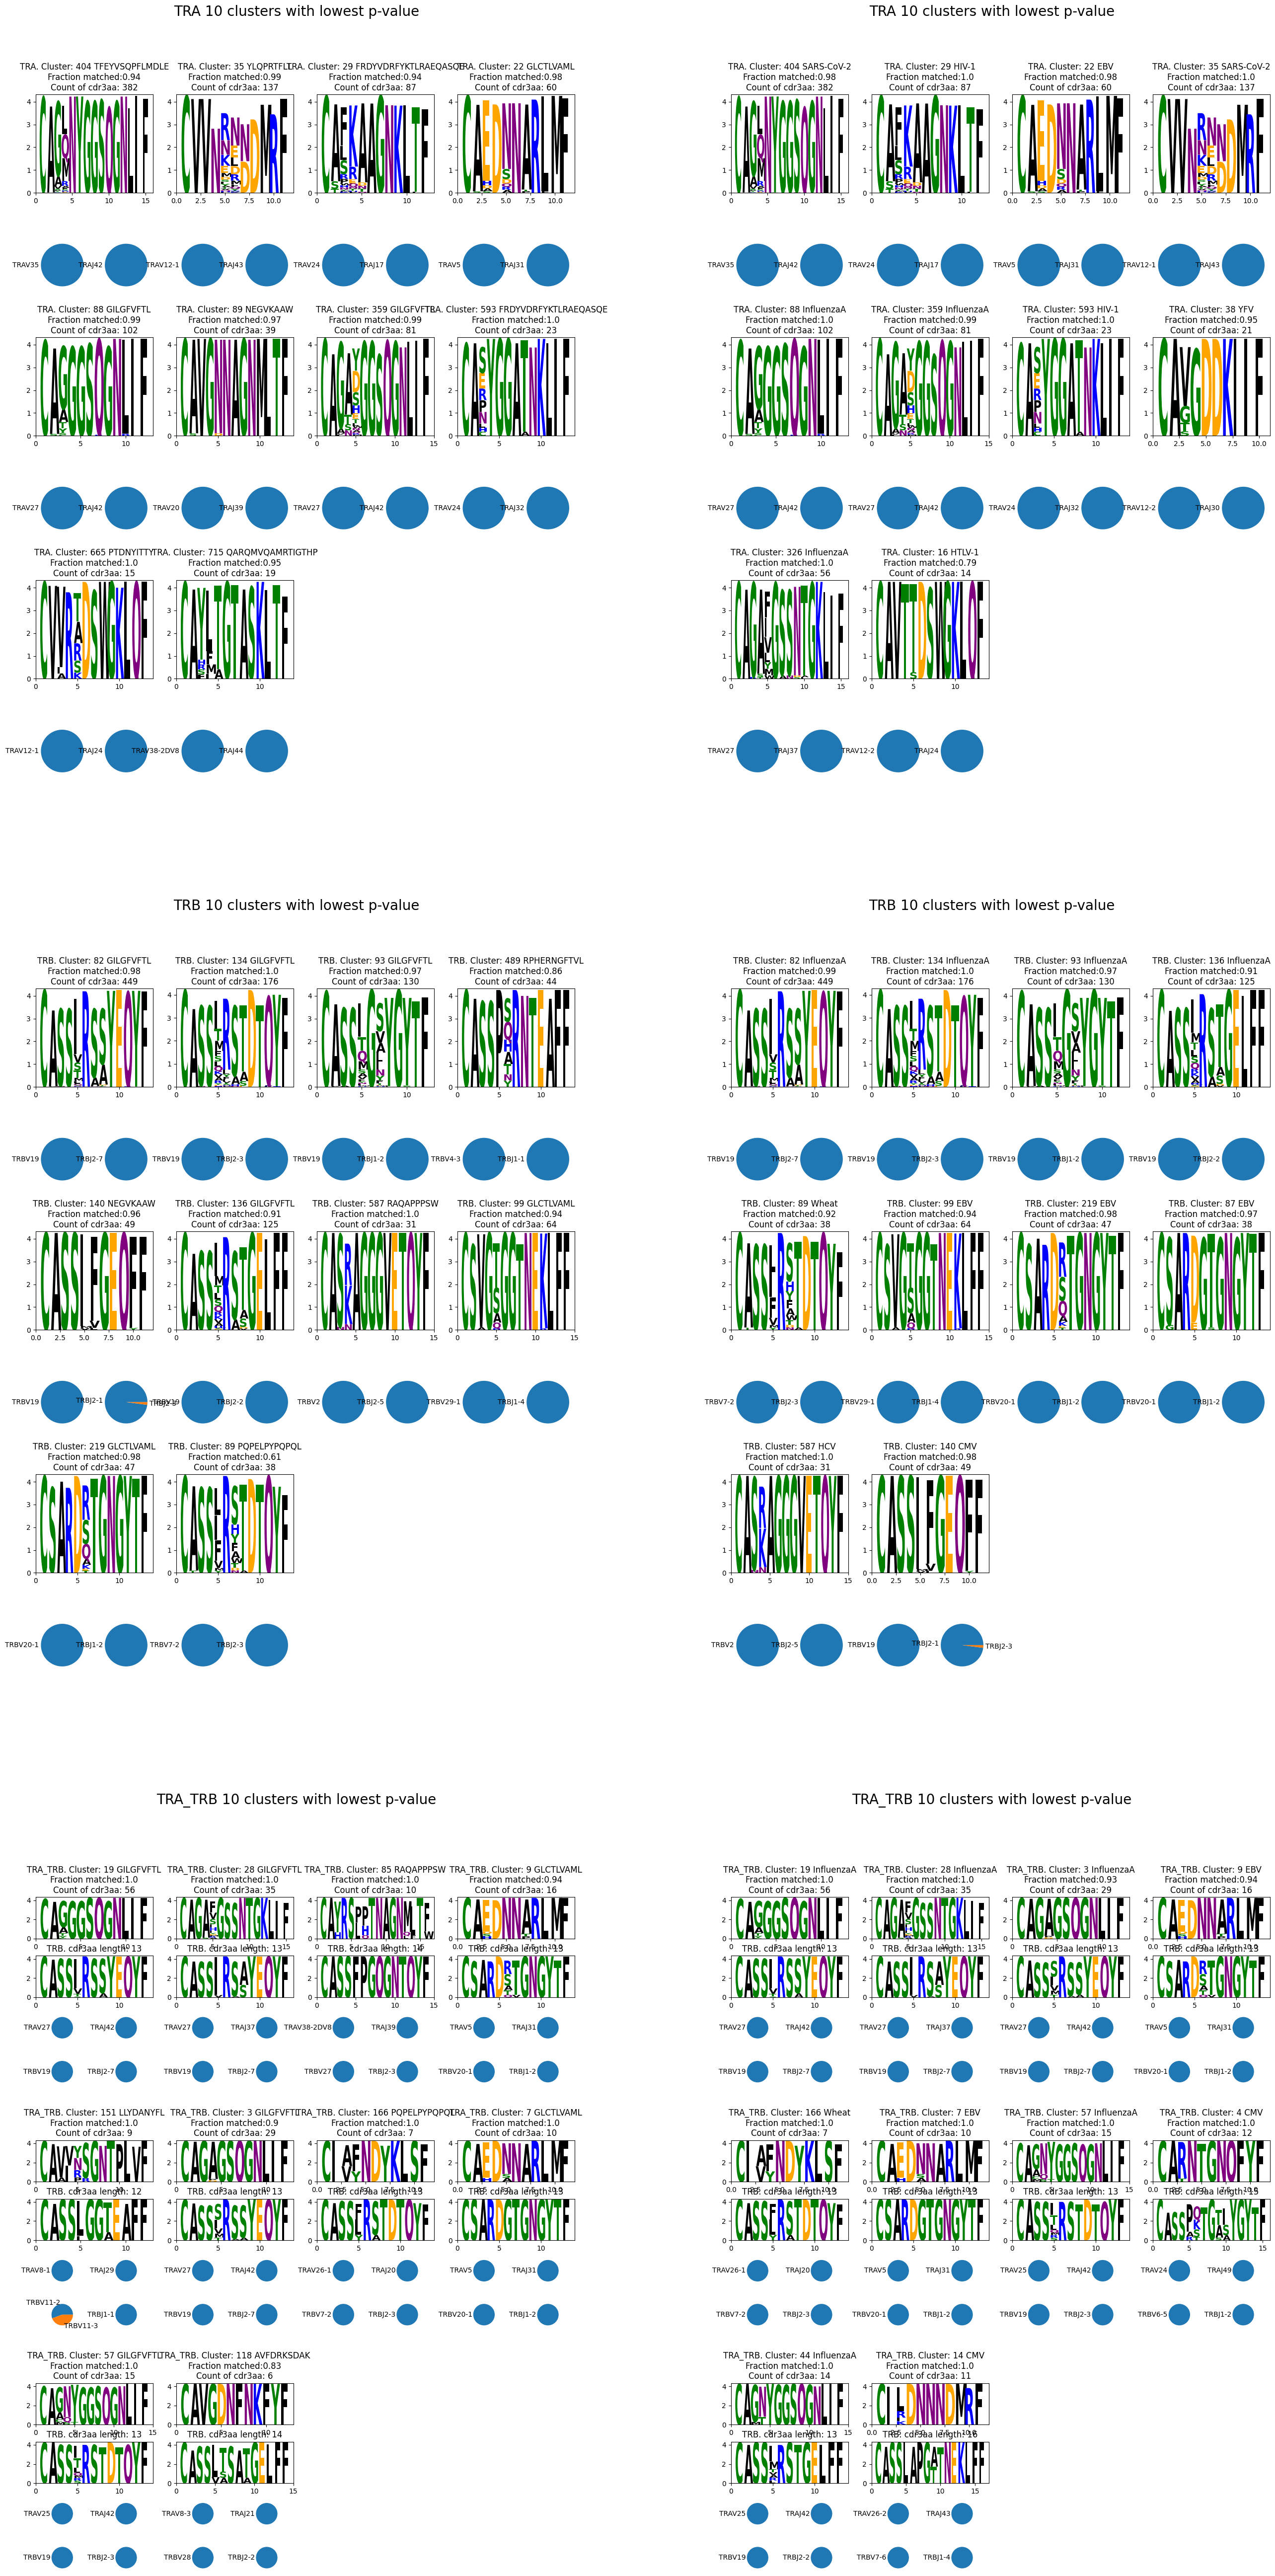

In [110]:
fig = plt.figure(figsize=(7*4,6*9))
subfigs = fig.subfigures(3, 2)

dbscan.clstrs_motif(tcremp,'TRA', 10, subfigs[0,0])
subfigs[0,0].suptitle('TRA 10 clusters with lowest p-value',fontsize=20)
dbscan.clstrs_motif(tcremp, 'TRB', 10, subfigs[1,0])
subfigs[1,0].suptitle('TRB 10 clusters with lowest p-value',fontsize=20)
dbscan.clstrs_motif(tcremp, 'TRA_TRB', 10, subfigs[2,0])
subfigs[2,0].suptitle('TRA_TRB 10 clusters with lowest p-value',fontsize=20)


dbscan_s.clstrs_motif(tcremp,'TRA', 10, subfigs[0,1])
subfigs[0,1].suptitle('TRA 10 clusters with lowest p-value',fontsize=20)
dbscan_s.clstrs_motif(tcremp, 'TRB', 10, subfigs[1,1])
subfigs[1,1].suptitle('TRB 10 clusters with lowest p-value',fontsize=20)
dbscan_s.clstrs_motif(tcremp, 'TRA_TRB', 10, subfigs[2,1])
subfigs[2,1].suptitle('TRA_TRB 10 clusters with lowest p-value',fontsize=20)

plt.savefig(f"results/figures/fig_sup_dbscan_epi_s.png")

In [29]:
import tcremp.motif_logo as motif_logo
import matplotlib.gridspec as gridspec
def clstrs_motif(kmeans,data, chain, n_head_clstrs, sfig=None):
    if (chain=='TRA') or (chain=='TRB'):
        plt_clusters = list(kmeans.binom_res[chain].sort_values('p_value').head(n_head_clstrs)['cluster'])
        clstr_data = pd.merge(kmeans.clstr_labels[chain],data.annot[chain])
    
        clstr_data['cdr3aa_len'] = clstr_data['cdr3aa'].apply(len)
        
        #n_rows = math.ceil(len(plt_clusters)/4) +1
        n_rows = math.ceil(len(plt_clusters)/4)
        if sfig is None:
            sfig = plt.figure(figsize=(28,7*n_rows))
            outer_grid = gridspec.GridSpec(n_rows, 4,figure=sfig)        
        else:
            outer_grid = gridspec.GridSpec(n_rows, 4,figure=sfig)
        
        gs = []
        ax_list = []
        for i in range(len(plt_clusters)):
            cl_row = math.ceil((i+1)/4)-1
            cl_col = i%4
            gs.append(outer_grid[cl_row,cl_col].subgridspec(6, 2))
            ax_list.append([sfig.add_subplot(gs[i][:3, :2])
                            ,sfig.add_subplot(gs[i][4:6, 0])
                            ,sfig.add_subplot(gs[i][4:6, 1])])
    
            plot_logo(clstr_data, chain, plt_clusters[i], ax_list[i])

    elif chain=='TRA_TRB':
        plt_clusters = list(data.binom_res[chain].sort_values('p_value').head(n_head_clstrs)['cluster'])
        clstr_data = pd.merge(data.clstr_labels[chain],data.annot[chain])
        
        clstr_data['a_cdr3aa_len'] = clstr_data['a_cdr3aa'].apply(len)
        clstr_data['b_cdr3aa_len'] = clstr_data['b_cdr3aa'].apply(len)
    
        #n_rows = math.ceil(len(plt_clusters)/4) +1
        n_rows = math.ceil(len(plt_clusters)/4)
        
        if sfig is None:
            sfig = plt.figure(figsize=(28,8*n_rows))
            outer_grid = gridspec.GridSpec(n_rows, 4,figure=sfig)        
        else:
            outer_grid = gridspec.GridSpec(n_rows, 4,figure=sfig)
        
        outer_grid = gridspec.GridSpec(n_rows, 4,figure=fig)
        gs = []
        ax_list = []
        for i in range(len(plt_clusters)):
            cl_row = math.ceil((i+1)/4)-1
            cl_col = i%4
            gs.append(outer_grid[cl_row,cl_col].subgridspec(14, 2))
            ax_list.append([sfig.add_subplot(gs[i][1:4, :2])
                            ,sfig.add_subplot(gs[i][5:8, :2])
                            ,sfig.add_subplot(gs[i][9:11, 0])
                            ,sfig.add_subplot(gs[i][9:11, 1])
                            ,sfig.add_subplot(gs[i][12:14, 0])
                            ,sfig.add_subplot(gs[i][12:14, 1])])
    
            self.__plot_logo_paired(clstr_data, chain, plt_clusters[i], ax_list[i])
    else:
        print('chain is incorrect')
        
        
def plot_logo(clstr_data, chain, c, list_ax):
        
    cluster_df = clstr_data[clstr_data['cluster']==c]
    lengs = cluster_df['cdr3aa_len'].drop_duplicates()
    fr_matched = cluster_df['fraction_matched'].drop_duplicates().reset_index(drop=True)[0]
    epi = cluster_df['label_cluster'].drop_duplicates().reset_index(drop=True)[0]
    total_cl = cluster_df['total_cluster'].drop_duplicates().reset_index(drop=True)[0]
    alphabet = [aa for aa in 'ARNDCQEGHILKMFPSTWYVBZX-']
    for l in lengs:
        seqs = cluster_df[cluster_df['cdr3aa_len']==l]['cdr3aa'].reset_index(drop=True)
        if len(seqs) > 4:
            motif_logo.plot_amino_logo(seqs, 'title',ax = list_ax[0])
            list_ax[0].set_title(f"{chain}. Cluster: {c} {epi}\nFraction matched:{round(fr_matched,2)}\nCount of cdr3aa: {len(seqs)}")
    plot_v_j = clstr_data[clstr_data['cluster']==c]

        
    plot_v_j = pd.DataFrame(plot_v_j.groupby('v')['cdr3aa'].count().reset_index())
    list_ax[1].pie(plot_v_j['cdr3aa'],labels=plot_v_j['v'])


    plot_v_j = clstr_data[clstr_data['cluster']==c]
    plot_v_j = pd.DataFrame(plot_v_j.groupby('j')['cdr3aa'].count().reset_index())
    list_ax[2].pie(plot_v_j['cdr3aa'],labels=plot_v_j['j'])   

## classification

### RF

In [17]:
clf = tcremp.tcremp_clf('RF_freq')
#clf_100 = tcremp.tcremp_clf('RF_freq')

In [18]:

chain='TRA'
max_depth = 20
model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clf.clf(chain,tcremp, label_high, model=model,test_size=0.15)

Train accuracy: 0.9904686258935663
Test accuracy: 0.45556805399325084
macro: {'f1': 0.31781814397374974, 'precision': 0.2663000633526532, 'recall': 0.5064302307347868}
weighted: {'f1': 0.48645227530216684, 'precision': 0.6002063159550638, 'recall': 0.45556805399325084}


In [19]:
chain='TRB'
max_depth = 20
model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clf.clf(chain,tcremp, label_high, model, test_size=0.15)

Train accuracy: 0.9751903709162368
Test accuracy: 0.4954077372669079
macro: {'f1': 0.27056803011677166, 'precision': 0.22708934687916466, 'recall': 0.6589715291859723}
weighted: {'f1': 0.5684472937379411, 'precision': 0.8121906183145472, 'recall': 0.4954077372669079}


In [20]:
chain='TRA_TRB'
max_depth = 20
model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clf.clf(chain,tcremp, label_high, model, test_size=0.15)

Train accuracy: 0.9837642814191221
Test accuracy: 0.5527809307604994
macro: {'f1': 0.17310610245884692, 'precision': 0.15732614833731978, 'recall': 0.4691079107228176}
weighted: {'f1': 0.6683178427124942, 'precision': 0.9083265417928306, 'recall': 0.5527809307604994}


accuracy: 0.46
f1_weighted:0.49
precision:0.6
recall:0.46
accuracy: 0.5
f1_weighted:0.57
precision:0.81
recall:0.5
accuracy: 0.55
f1_weighted:0.67
precision:0.91
recall:0.55


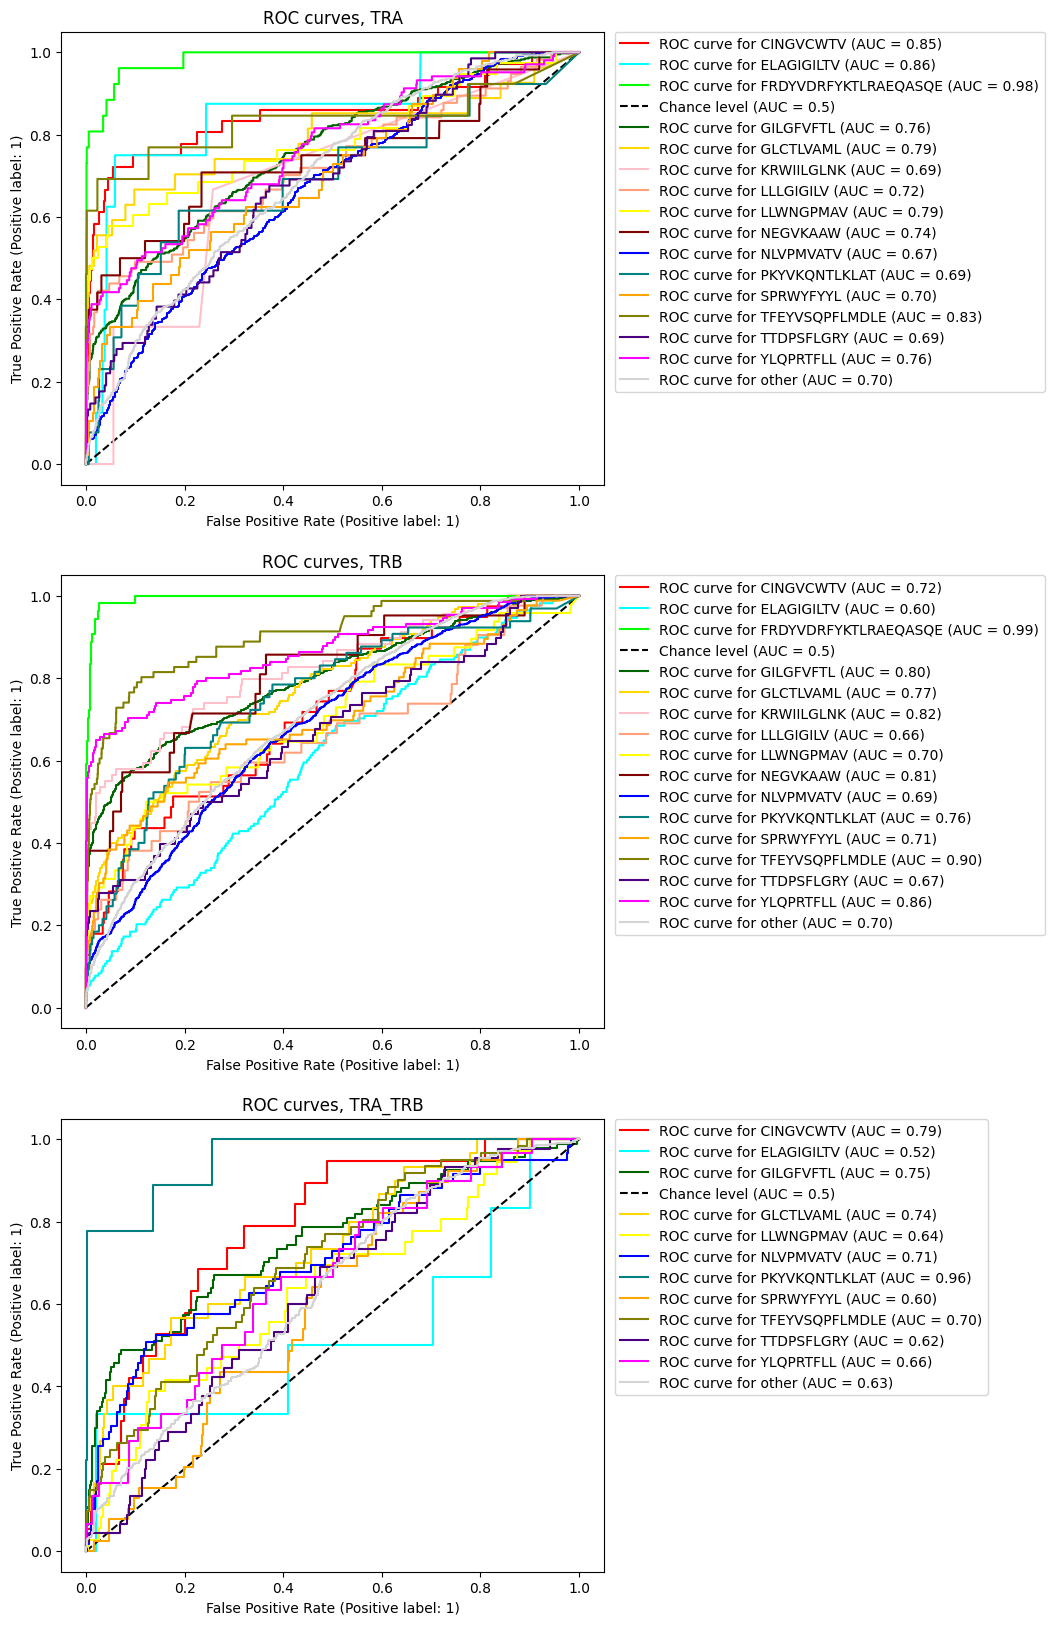

In [21]:
fig, axs = plt.subplots(3, 1, figsize=(7,20))
clf.roc_auc('TRA',custom_palette=custom_palette, ax=axs[0])
clf.roc_auc('TRB',custom_palette=custom_palette, ax=axs[1])
clf.roc_auc('TRA_TRB',custom_palette=custom_palette, ax=axs[2])
#plt.savefig("results/figures/vdjdb_rf.png",bbox_inches='tight')

if unique_clonotypes:
    plt.savefig("results/figures/vdjdb_rf_unique_clonotypes.png",bbox_inches='tight')
else:
    plt.savefig("results/figures/vdjdb_rf_tsne.png",bbox_inches='tight')

accuracy: 0.63
f1_weighted:0.66
precision:0.82
recall:0.63


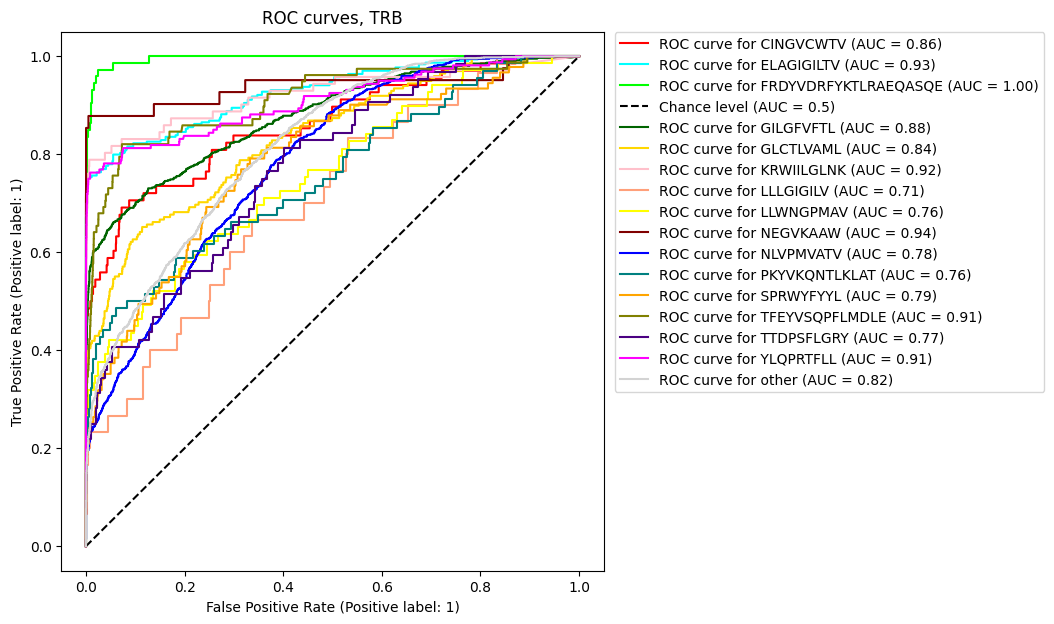

In [20]:
clf.roc_auc('TRB',custom_palette=custom_palette)

accuracy: 0.61
f1_weighted:0.68
precision:0.86
recall:0.61


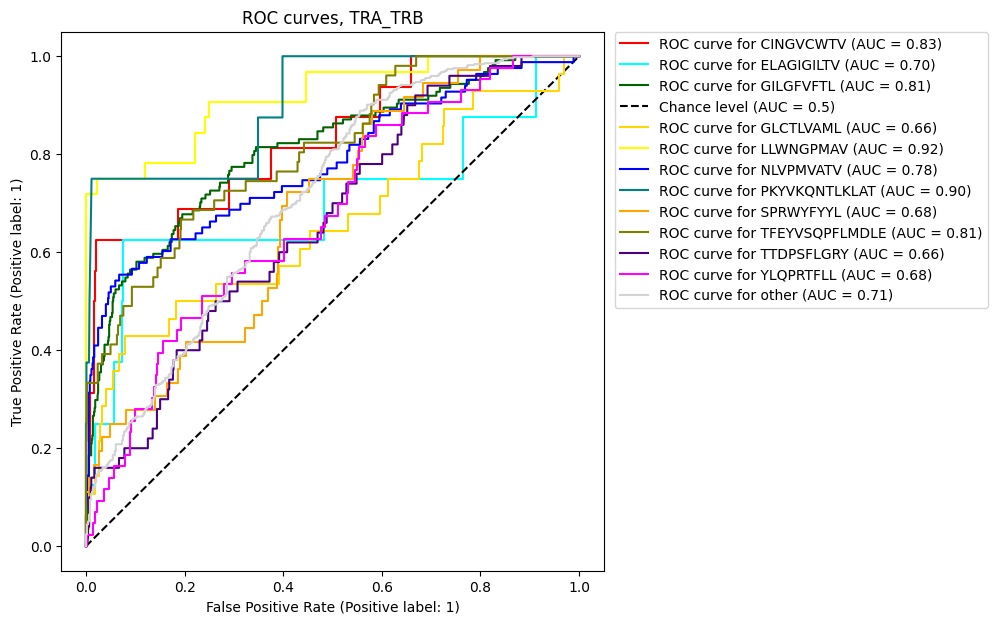

In [21]:
clf.roc_auc('TRA_TRB',custom_palette=custom_palette)

In [35]:

chain='TRA'
max_depth = 20
model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clf_100.clf(chain,tcremp_100, label_high, model=model,test_size=0.15)

Train accuracy: 0.9737047898338221
Test accuracy: 0.46234772978959027
macro: {'f1': 0.35935283832233667, 'precision': 0.3122602049306057, 'recall': 0.4997767584648407}
weighted: {'f1': 0.4935309266784134, 'precision': 0.6058821359435311, 'recall': 0.46234772978959027}


In [36]:

chain='TRB'
max_depth = 20
model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clf_100.clf(chain,tcremp_100, label_high, model=model,test_size=0.15)

Train accuracy: 0.9661091334666212
Test accuracy: 0.5138121546961326
macro: {'f1': 0.2899020902090774, 'precision': 0.24013216442287563, 'recall': 0.7025952104289664}
weighted: {'f1': 0.5851219893957911, 'precision': 0.7959271234075305, 'recall': 0.5138121546961326}


accuracy: 0.45
f1_weighted:0.49
precision:0.63
recall:0.45


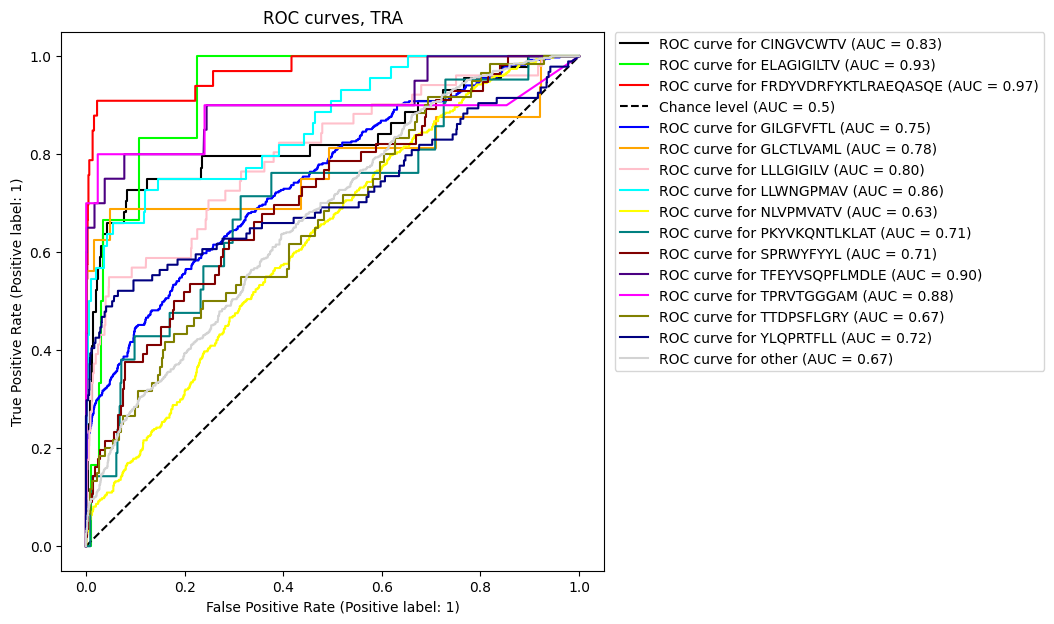

In [37]:
clf.roc_auc('TRA',custom_palette=custom_palette)

accuracy: 0.46
f1_weighted:0.49
precision:0.61
recall:0.46


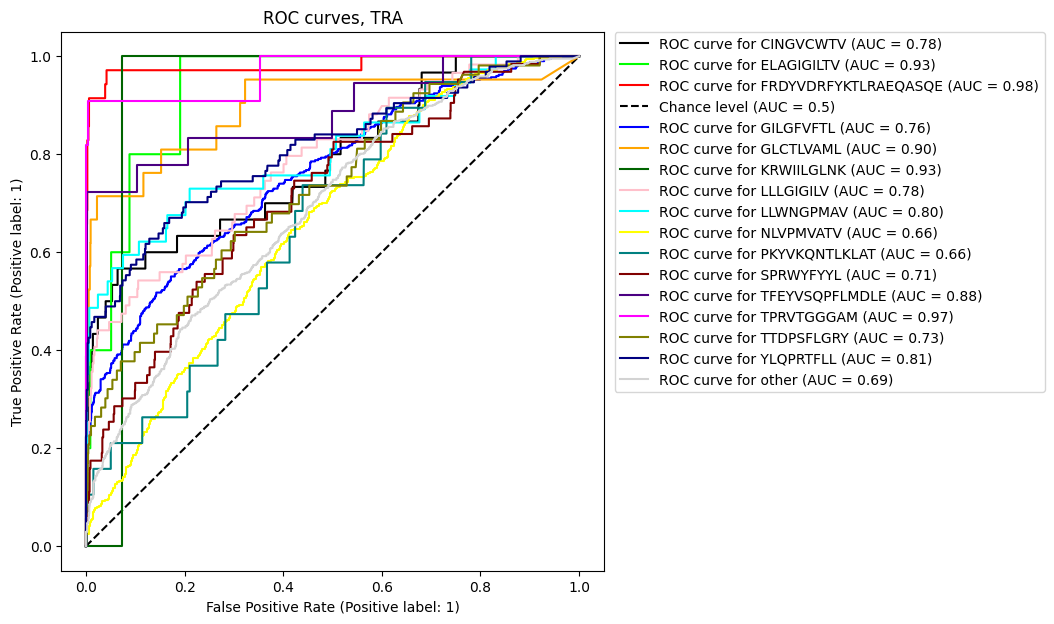

In [38]:
clf_100.roc_auc('TRA',custom_palette=custom_palette)

In [24]:
clf.roc_auc_proba_df['TRA'].sort_values('class')

,class,roc_auc
0,CINGVCWTV,0.788259
1,ELAGIGILTV,0.849968
2,FRDYVDRFYKTLRAEQASQE,0.980556
3,GILGFVFTL,0.722378
4,GLCTLVAML,0.821572
5,KRWIILGLNK,NaN
6,LLLGIGILV,0.825648
7,LLWNGPMAV,0.771896
8,NLVPMVATV,0.633029
9,PKYVKQNTLKLAT,0.598260


accuracy: 0.5
f1_weighted:0.58
precision:0.8
recall:0.5


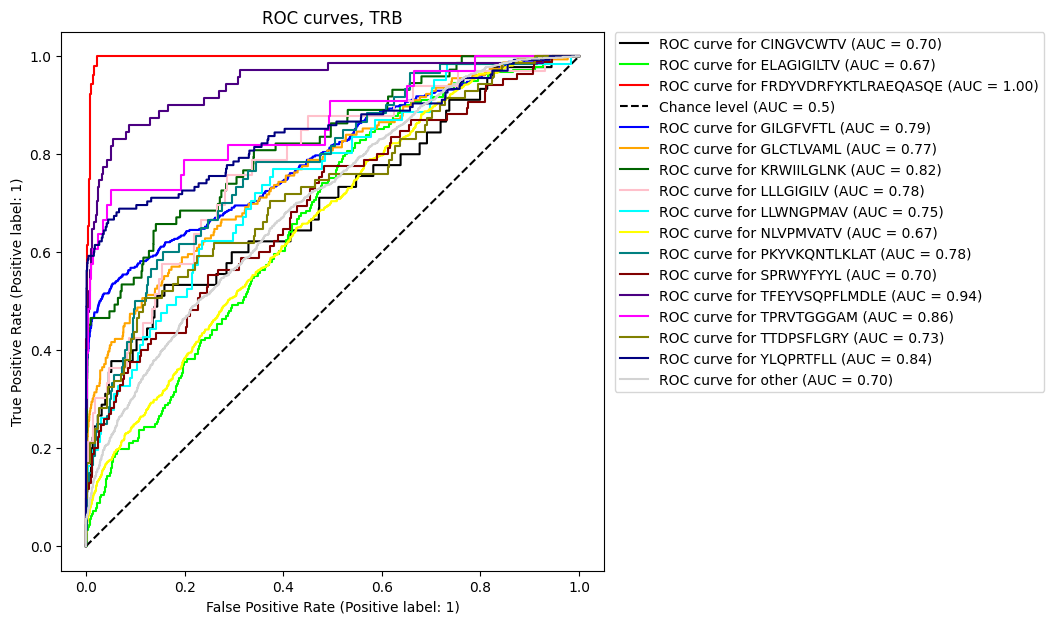

In [25]:
clf.roc_auc('TRB',custom_palette=custom_palette)

In [26]:
clf.roc_auc_proba_df['TRB'].sort_values('class')

,class,roc_auc
0,CINGVCWTV,0.701852
1,ELAGIGILTV,0.668807
2,FRDYVDRFYKTLRAEQASQE,0.996087
3,GILGFVFTL,0.794946
4,GLCTLVAML,0.769175
5,KRWIILGLNK,0.822542
6,LLLGIGILV,0.784271
7,LLWNGPMAV,0.746765
8,NLVPMVATV,0.665077
9,PKYVKQNTLKLAT,0.783450


In [38]:
clf_all = tcremp.tcremp_clf('RF_all')
chain='TRA'
max_depth = 20
model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clf_all.clf(chain,tcremp, label, model=model,test_size=0.15)

Train accuracy: 0.9491691104594331
Test accuracy: 0.35603543743078625
macro: {'f1': 0.06173004408220069, 'precision': 0.054442683269622566, 'recall': 0.08923086537145436}
weighted: {'f1': 0.40104034502742697, 'precision': 0.5607806309734921, 'recall': 0.35603543743078625}


In [39]:

chain='TRB'
max_depth = 20
model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clf_all.clf(chain,tcremp, label, model=model,test_size=0.15)

Train accuracy: 0.9450919198322524
Test accuracy: 0.33812154696132596
macro: {'f1': 0.05708279882719553, 'precision': 0.04680162431193076, 'recall': 0.11403861554062761}
weighted: {'f1': 0.4014099107178122, 'precision': 0.7557508234383808, 'recall': 0.33812154696132596}


In [45]:
clf_all.clsf_metrics

{'TRA': {'train_acc': 0.9491691104594331,
  'test_acc': 0.35603543743078625,
  'f1_macro': {'f1': 0.06173004408220069,
   'precision': 0.054442683269622566,
   'recall': 0.08923086537145436},
  'f1_weighted': {'f1': 0.40104034502742697,
   'precision': 0.5607806309734921,
   'recall': 0.35603543743078625}},
 'TRB': {'train_acc': 0.9450919198322524,
  'test_acc': 0.33812154696132596,
  'f1_macro': {'f1': 0.05708279882719553,
   'precision': 0.04680162431193076,
   'recall': 0.11403861554062761},
  'f1_weighted': {'f1': 0.4014099107178122,
   'precision': 0.7557508234383808,
   'recall': 0.33812154696132596}}}

In [48]:
roc_auc_trb_all = clf_all.roc_auc_proba_df['TRB'].sort_values('class')

In [49]:
epitopes_list = ['CINGVCWTV',
 'ELAGIGILTV',
 'FRDYVDRFYKTLRAEQASQE',
 'GILGFVFTL',
 'GLCTLVAML',
 'KRWIILGLNK',
 'LLLGIGILV',
 'LLWNGPMAV',
 'NLVPMVATV',
 'PKYVKQNTLKLAT',
 'SPRWYFYYL',
 'TFEYVSQPFLMDLE',
 'TPRVTGGGAM',
 'TTDPSFLGRY',
 'YLQPRTFLL']

In [50]:
roc_auc_trb_all[roc_auc_trb_all['class'].isin(epitopes_list)]

,class,roc_auc
70,CINGVCWTV,0.689056
118,ELAGIGILTV,0.636864
210,FRDYVDRFYKTLRAEQASQE,0.994598
249,GILGFVFTL,0.787949
252,GLCTLVAML,0.766211
409,KRWIILGLNK,0.783626
448,LLLGIGILV,0.698356
458,LLWNGPMAV,0.758839
580,NLVPMVATV,0.658925
606,PKYVKQNTLKLAT,0.691419


In [51]:
atm_res = [{'class': 'CINGVCWTV', 'roc_auc': 0.5752120257985882},
 {'class': 'ELAGIGILTV', 'roc_auc': 0.515489498116114},
 {'class': 'FRDYVDRFYKTLRAEQASQE', 'roc_auc': 0.677350859453994},
 {'class': 'GILGFVFTL', 'roc_auc': 0.5704231955814368},
 {'class': 'GLCTLVAML', 'roc_auc': 0.5417590286425903},
 {'class': 'KRWIILGLNK', 'roc_auc': 0.5725415070242657},
 {'class': 'LLLGIGILV', 'roc_auc': 0.5764722698684963},
 {'class': 'LLWNGPMAV', 'roc_auc': 0.5477210630899155},
 {'class': 'NLVPMVATV', 'roc_auc': 0.5250316938946034},
 {'class': 'PKYVKQNTLKLAT', 'roc_auc': 0.5584946899431166},
 {'class': 'SPRWYFYYL', 'roc_auc': 0.5273414985590779},
 {'class': 'TFEYVSQPFLMDLE', 'roc_auc': 0.730540427314621},
 {'class': 'TPRVTGGGAM', 'roc_auc': 0.6228962818003914},
 {'class': 'TTDPSFLGRY', 'roc_auc': 0.5266290726817043},
 {'class': 'YLQPRTFLL', 'roc_auc': 0.6320013101867017}]

In [52]:
atm_res = pd.DataFrame(atm_res)

In [53]:
atm_res = atm_res.rename({'roc_auc':'auc_atm_tcr'},axis=1)
roc_auc_trb_all = roc_auc_trb_all = roc_auc_trb_all.rename({'roc_auc':'auc_tcremp'},axis=1)

In [54]:
roc_auc_trb_all.merge(atm_res)

,class,auc_tcremb,auc_atm_tcr
0,CINGVCWTV,0.689056,0.575212
1,ELAGIGILTV,0.636864,0.515489
2,FRDYVDRFYKTLRAEQASQE,0.994598,0.677351
3,GILGFVFTL,0.787949,0.570423
4,GLCTLVAML,0.766211,0.541759
5,KRWIILGLNK,0.783626,0.572542
6,LLLGIGILV,0.698356,0.576472
7,LLWNGPMAV,0.758839,0.547721
8,NLVPMVATV,0.658925,0.525032
9,PKYVKQNTLKLAT,0.691419,0.558495


In [50]:
clf_500 = tcremp.tcremp_clf('RF_freq_500')
chain='TRA'
max_depth = 20
model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clf_500.clf(chain,tcremp, str(label + '_freq_500'), model=model,test_size=0.15)

Train accuracy: 0.9733137829912023
Test accuracy: 0.46511627906976744
macro: {'f1': 0.3599265081050936, 'precision': 0.3112033933016937, 'recall': 0.49928079315785256}
weighted: {'f1': 0.4984751706125958, 'precision': 0.6200784935512256, 'recall': 0.46511627906976744}


In [51]:
chain='TRB'
max_depth = 20
model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clf_500.clf(chain,tcremp, str(label + '_freq_500'), model=model,test_size=0.15)

Train accuracy: 0.971375627834398
Test accuracy: 0.5461325966850828
macro: {'f1': 0.280768584459444, 'precision': 0.24561790517595558, 'recall': 0.5838798872961479}
weighted: {'f1': 0.618596198316942, 'precision': 0.8077928242774112, 'recall': 0.5461325966850828}


accuracy: 0.47
f1_weighted:0.5
precision:0.62
recall:0.47


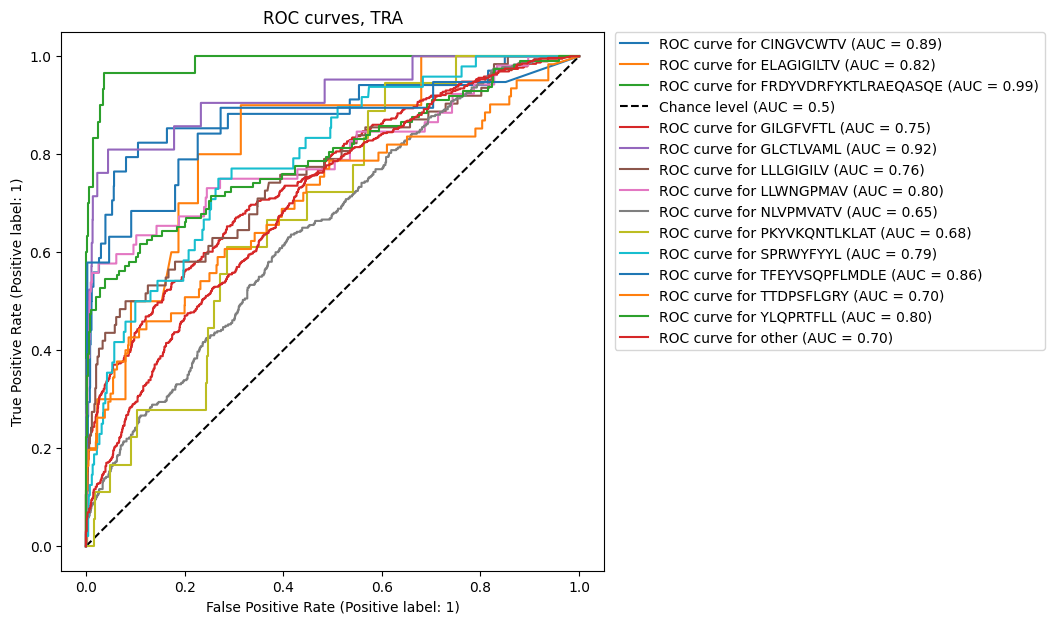

In [52]:
clf_500.roc_auc('TRA')

In [62]:
clf_500.roc_auc_proba_df['TRB'].sort_values('roc_auc')

,class,roc_auc
1,ELAGIGILTV,0.644633
7,NLVPMVATV,0.689330
5,LLLGIGILV,0.707848
13,other,0.710905
8,PKYVKQNTLKLAT,0.730024
6,LLWNGPMAV,0.738687
11,TTDPSFLGRY,0.759453
4,GLCTLVAML,0.760921
0,CINGVCWTV,0.785924
3,GILGFVFTL,0.803595


accuracy: 0.55
f1_weighted:0.62
precision:0.81
recall:0.55


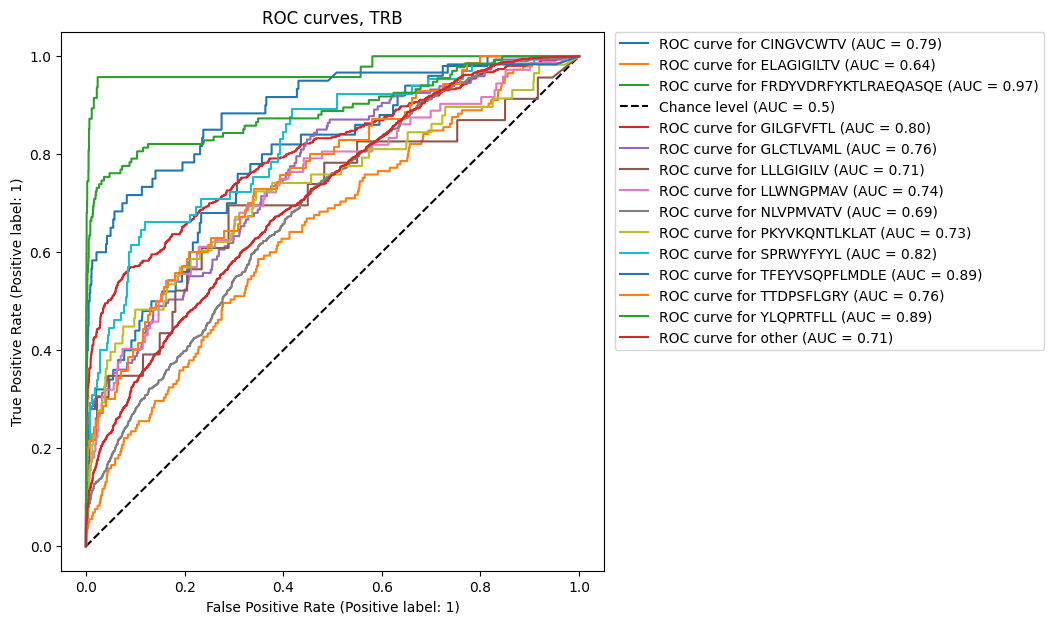

In [53]:
clf_500.roc_auc('TRB')

In [63]:
clf_100 = tcremp.tcremp_clf('RF_freq_100')
chain='TRA'
max_depth = 20
model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clf_100.clf(chain,tcremp, str(label + '_freq_100'), model=model,test_size=0.15)

Train accuracy: 0.9724340175953079
Test accuracy: 0.3853820598006645
macro: {'f1': 0.20265623372366806, 'precision': 0.16712937783072584, 'recall': 0.3195903583343941}
weighted: {'f1': 0.4038929796708792, 'precision': 0.45648099678254717, 'recall': 0.3853820598006645}


In [64]:

chain='TRB'
max_depth = 20
model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clf_100.clf(chain,tcremp, str(label + '_freq_100'), model=model,test_size=0.15)

Train accuracy: 0.9795679524064953
Test accuracy: 0.37596685082872927
macro: {'f1': 0.18172206575985597, 'precision': 0.14331505043970866, 'recall': 0.48213104413470853}
weighted: {'f1': 0.41405696847319207, 'precision': 0.5499677197958581, 'recall': 0.37596685082872927}


accuracy: 0.39
f1_weighted:0.4
precision:0.46
recall:0.39


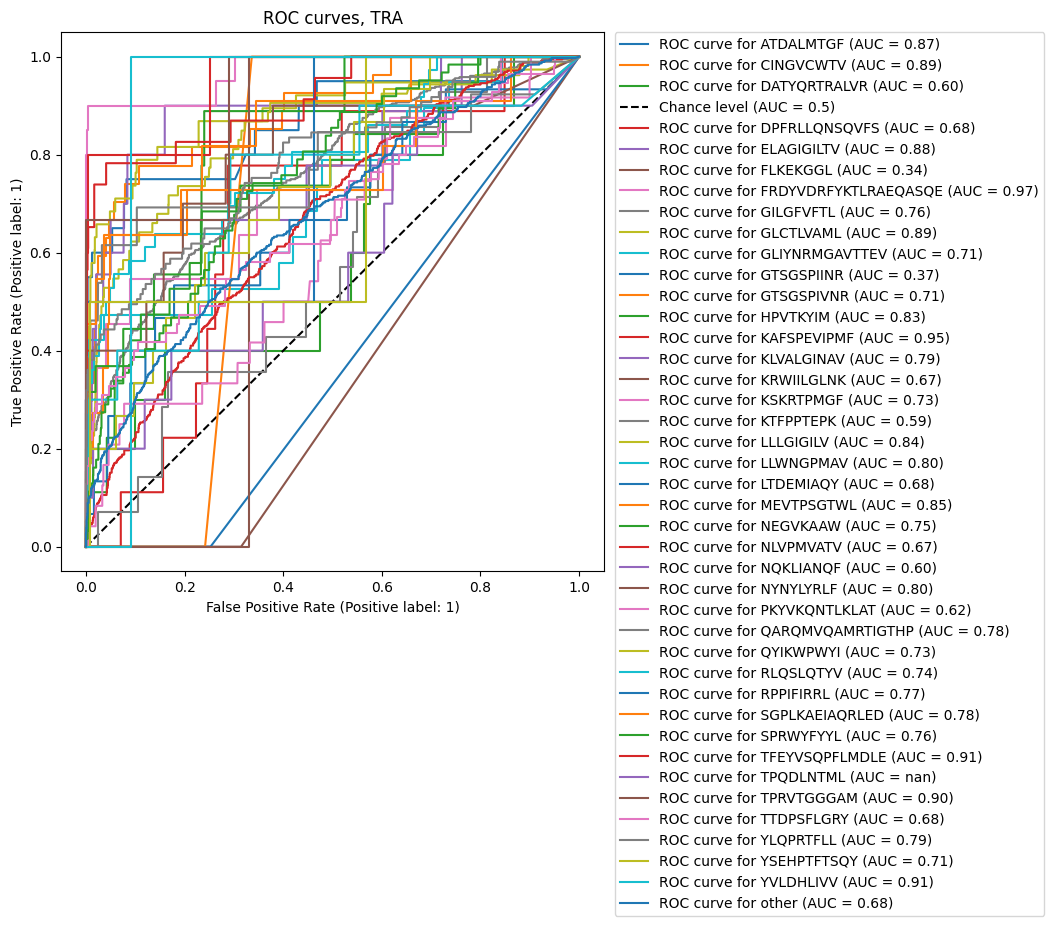

In [65]:
clf_100.roc_auc('TRA')

accuracy: 0.38
f1_weighted:0.41
precision:0.55
recall:0.38


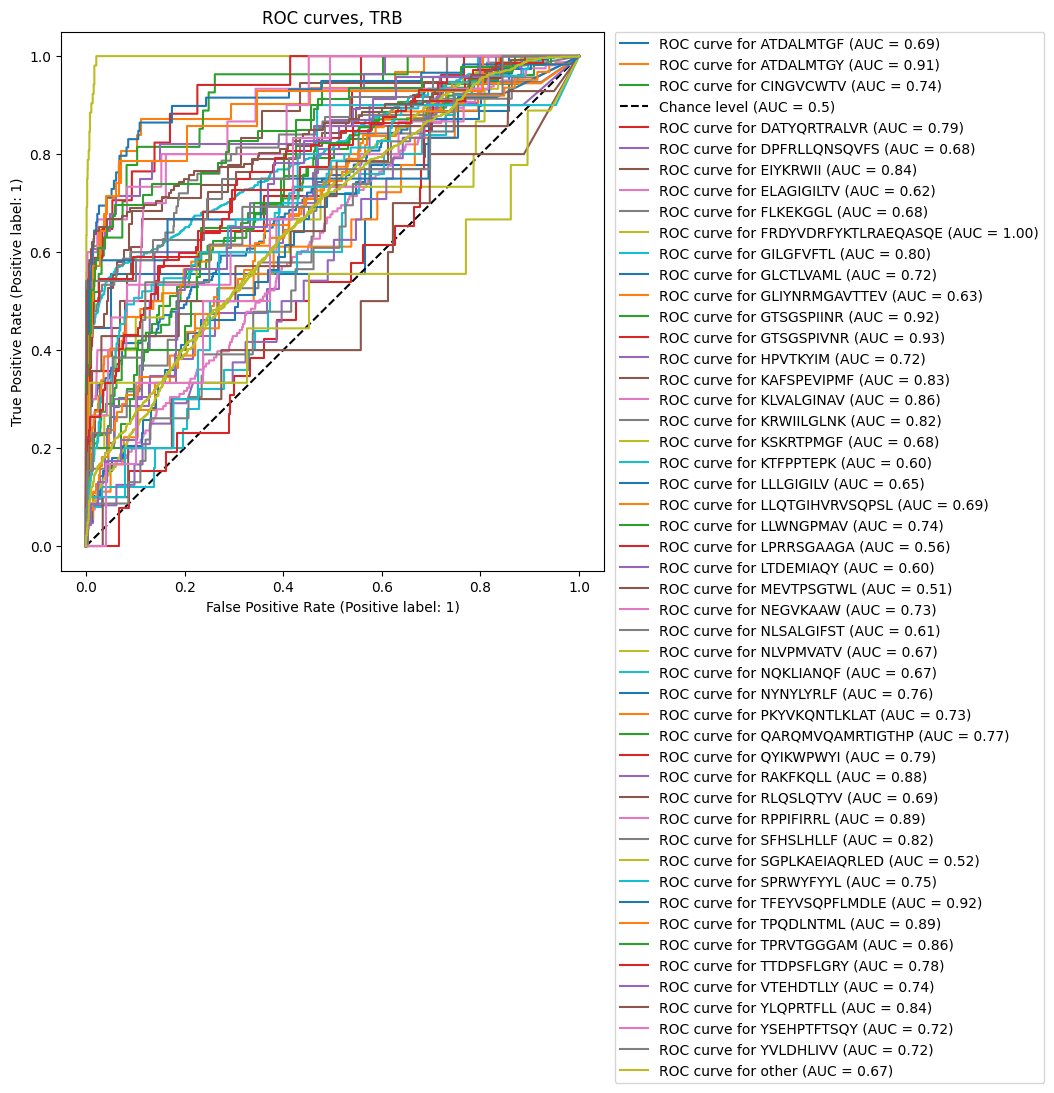

In [66]:
clf_100.roc_auc('TRB')

In [ ]:
clf = tcremp.tcremp_clf_bind('test')
chain='TRA'
max_depth = 20
model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clf.clf(chain,tcremp, label,model=model,labels_list = ['GILGFVFTL','YLQPRTFLL','GLCTLVAML','NLVPMVATV'],test_size=0.15)

In [ ]:
from sklearn.model_selection import cross_val_score



In [ ]:
def clf_model(model, label_np, proc_df, annotation_id_column, chain, test_size = 0.3 ,show_legend=True, ax=None):
    
    y_train, y_test,X_train, X_test,  = train_test_split(label_np, proc_df.drop(annotation_id_column, axis=1, errors = 'ignore') ,test_size=test_size)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)   
    print(f'Train accuracy: {model.score(X_train,y_train)}')
    print(f'Test accuracy: {model.score(X_test,y_test)}')
    print(f"macro: {tcremp_code2.clsf_metrics(pred,y_test,'macro')}")
    print(f"weighted: {tcremp_code2.clsf_metrics(pred,y_test,'weighted')}")
    
    print(f'cross_val_score: {cross_val_score(model, proc_df.drop(annotation_id_column, axis=1, errors = "ignore"), label_np, cv=5, scoring="accuracy")}')
    print(f'cross_val_score f1_weighted: {cross_val_score(model, proc_df.drop(annotation_id_column, axis=1, errors = "ignore"), label_np, cv=5, scoring="f1_weighted")}')
    
    
    roc_auc_df = tcremp_code2.roc_auc(model, pred, y_test, X_test, chain, show_legend, ax)
    
    return model, roc_auc_df.sort_values('roc_auc',ascending=False)

In [ ]:
clsf_dict = {}

In [ ]:
model_name = 'RF_label_20'
label_cl = label+'_freq_20'
clsf_dict[model_name]= {'model':{},'roc_auc':{}}

In [ ]:
chain = 'TRA'
max_depth = 20


y_data = tcremp['annot'][chain][label]
X_data = tcremp['pca'][chain]


model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = tcremp_code2.clf_model(model,y_data, X_data , annotation_id, chain)



In [ ]:
chain = 'TRB'
max_depth = 20

y_data = tcremp['annot'][chain][label]
X_data = tcremp['pca'][chain]


model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = tcremp_code2.clf_model(model,y_data, X_data , annotation_id, chain)


In [ ]:
model_name = 'RF_label_100'
label_cl = label+'_freq_100'
clsf_dict[model_name]= {'model':{},'roc_auc':{}}

In [ ]:
chain = 'TRA'
max_depth = 20


y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]


model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = clf_model(model,y_data, X_data , annotation_id, chain)



In [ ]:
chain = 'TRB'
max_depth = 20

y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]


model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = clf_model(model,y_data, X_data , annotation_id, chain,show_legend=False)


In [ ]:
model_name = 'RF_label_200'
label_cl = label+'_freq_200'
clsf_dict[model_name]= {'model':{},'roc_auc':{}}

In [ ]:
chain = 'TRA'
max_depth = 20


y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]


model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = tcremp_code2.clf_model(model,y_data, X_data , annotation_id, chain)



In [ ]:
chain = 'TRB'
max_depth = 20

y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]


model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = tcremp_code2.clf_model(model,y_data, X_data , annotation_id, chain)


In [ ]:
model_name = 'RF_label_300'
label_cl = label+'_freq_300'
clsf_dict[model_name]= {'model':{},'roc_auc':{}}

In [ ]:
chain = 'TRA'
max_depth = 20


y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]


model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = tcremp_code2.clf_model(model,y_data, X_data , annotation_id, chain)



In [ ]:
chain = 'TRB'
max_depth = 20

y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]


model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = tcremp_code2.clf_model(model,y_data, X_data , annotation_id, chain,show_legend=False)


In [ ]:
model_name = 'RF_label_500'
label_cl = label+'_freq_300'
clsf_dict[model_name]= {'model':{},'roc_auc':{}}

In [ ]:
chain = 'TRA'
max_depth = 20


y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]


model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = tcremp_code2.clf_model(model,y_data, X_data , annotation_id, chain)



In [ ]:
chain = 'TRB'
max_depth = 20

y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]


model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = tcremp_code2.clf_model(model,y_data, X_data , annotation_id, chain)


In [ ]:
model_name = 'RF_label_1000'
label_cl = label+'_freq_1000'
clsf_dict[model_name]= {'model':{},'roc_auc':{}}

In [ ]:
chain = 'TRA'
max_depth = 20


y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]


model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = clf_model(model,y_data, X_data , annotation_id, chain) ##tcremp_code2.clf_model(model,y_data, X_data , annotation_id, chain)



In [ ]:
chain = 'TRB'
max_depth = 20

y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]


model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = clf_model(model,y_data, X_data , annotation_id, chain) ##tcremp_code2.clf_model(model,y_data, X_data , annotation_id, chain)


In [ ]:
model_name = 'RF_label_high'
label_cl = label_high
clsf_dict[model_name]= {'model':{},'roc_auc':{}}

In [ ]:
chain = 'TRA'
max_depth = 20


y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]


model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = tcremp_code2.clf_model(model,y_data, X_data , annotation_id, chain)



In [ ]:
chain = 'TRB'
max_depth = 20

y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]


model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = tcremp_code2.clf_model(model,y_data, X_data , annotation_id, chain)


In [ ]:
model_name = 'RF_label_high_s'
label_cl = label_high_s
clsf_dict[model_name]= {'model':{},'roc_auc':{}}

In [ ]:
chain = 'TRA'
max_depth = 20


y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]


model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = tcremp_code2.clf_model(model,y_data, X_data , annotation_id, chain)



In [ ]:
chain = 'TRB'
max_depth = 20

y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]


model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = tcremp_code2.clf_model(model,y_data, X_data , annotation_id, chain)


### SVM

In [ ]:
model_name = 'SVM_label_high'
label_cl = label_high
clsf_dict[model_name]= {'model':{},'roc_auc':{}}

In [ ]:
from sklearn.svm import SVC

In [ ]:
chain = 'TRA'
c = 6

y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]



model = SVC(C=c, random_state=0,probability=True)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain],y_train, y_test,X_train, X_test = tcremp_code2.clf_model_tt(model,y_data, X_data , annotation_id, chain, test_size = 0.15)


In [ ]:
chain = 'TRB'
c = 6

y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]



model = SVC(C=c, random_state=0,probability=True)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain],y_train, y_test,X_train, X_test = tcremp_code2.clf_model_tt(model,y_data, X_data , annotation_id, chain, test_size = 0.15)


In [ ]:
model_name = 'SVM_label_300'
label_cl = label+'_freq_300'
clsf_dict[model_name]= {'model':{},'roc_auc':{}}

In [ ]:
chain = 'TRA'
c = 6

y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]



model = SVC(C=c, random_state=0,probability=True, kernel='poly')
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = tcremp_code2.clf_model(model,y_data, X_data , annotation_id, chain)




In [ ]:
chain = 'TRB'
c = 6

y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]



model = SVC(C=c, random_state=0,probability=True, kernel='poly')
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = tcremp_code2.clf_model(model,y_data, X_data , annotation_id, chain)




In [ ]:
model_name = 'SVM_label_500'
label_cl = label+'_freq_500'
clsf_dict[model_name]= {'model':{},'roc_auc':{}}

In [ ]:
chain = 'TRA'
c = 6

y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]



model = SVC(C=c, random_state=0,probability=True, kernel='poly')
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = tcremp_code2.clf_model(model,y_data, X_data , annotation_id, chain)




In [ ]:
chain = 'TRB'
c = 6

y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]



model = SVC(C=c, random_state=0,probability=True, kernel='poly')
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = tcremp_code2.clf_model(model,y_data, X_data , annotation_id, chain)


In [ ]:
model_name = 'SVM_label_1000'
label_cl = label+'_freq_1000'
clsf_dict[model_name]= {'model':{},'roc_auc':{}}

In [ ]:
chain = 'TRA'
c = 6

y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]



model = SVC(C=c, random_state=0,probability=True, kernel='poly')
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = tcremp_code2.clf_model(model,y_data, X_data , annotation_id, chain)


In [ ]:
chain = 'TRB'
c = 6

y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]



model = SVC(C=c, random_state=0,probability=True, kernel='poly')
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = tcremp_code2.clf_model(model,y_data, X_data , annotation_id, chain)


In [ ]:
model_name = 'SVM_label_high_s'
label_cl = label_high_s
clsf_dict[model_name]= {'model':{},'roc_auc':{}}

In [ ]:
chain = 'TRA'
c = 6

y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]



model = SVC(C=c, random_state=0,probability=True, kernel='poly')
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = tcremp_code2.clf_model(model,y_data, X_data , annotation_id, chain)




In [ ]:
chain = 'TRB'
c = 6

y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]



model = SVC(C=c, random_state=0,probability=True)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = tcremp_code2.clf_model(model,y_data, X_data , annotation_id, chain)


In [ ]:
model_name = 'SVM_ovr'
label_cl = label
clsf_dict[model_name]= {'model':{},'roc_auc':{}}

In [ ]:
from sklearn.multiclass import OneVsRestClassifier

In [ ]:
chain = 'TRB'
c = 6

y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]



model = OneVsRestClassifier(SVC())
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = tcremp_code2.clf_model(model,y_data, X_data , annotation_id, chain)

In [ ]:
pd.DataFrame(clsf_dict[model_name]['roc_auc'][chain]).head(30)

In [ ]:
## with label_high
chain = 'TRB'
model_name = 'SVC_ovr'
clsf_dict[model_name]= {'model':{}, 'roc_auc':{}}

clf_rf_model = OneVsRestClassifier(SVC())
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = tcremp_code.clf_model(clf_rf_model,pca_res_annot_dict[chain][label_high], pca_res_dict[chain] , annotation_id_column_dict[chain], 0.3)


In [ ]:
pd.DataFrame(clsf_dict[model_name]['roc_auc'][chain]).head(30)

In [39]:
!pwd

/home/ykremlyakova/projects/tcr_emb_mirpy_old


## Fig

In [57]:
t

,antigen.epitope_high_count_1000,cdr3
0,ELAGIGILTV,1159
1,GILGFVFTL,5574
2,GLCTLVAML,1140
3,NLVPMVATV,7059
4,YLQPRTFLL,1566
5,other,19695


([<matplotlib.patches.Wedge at 0x7fda456f6ed0>,
 [Text(1.0944382197910936, 0.11047616512398618, 'ELAGIGILTV'),
  Text(0.851837011373225, 0.6959696157554095, 'GILGFVFTL'),
  Text(0.3282015748821189, 1.0498970074463958, 'GLCTLVAML'),
  Text(-0.4371614909693769, 1.0094007285580051, 'NLVPMVATV'),
  Text(-1.0073213862028194, 0.4419316970963164, 'YLQPRTFLL'),
  Text(-0.15213737562761476, -1.0894283909175226, 'other')])

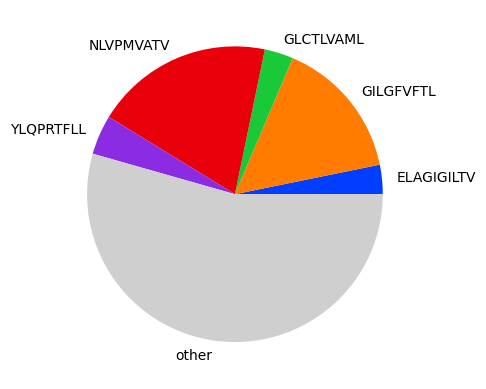

In [63]:
t = pd.DataFrame(data_prebuilt.groupby(str(label+'_freq_1000'))['cdr3aa'].count().reset_index())
custom_palette = ml_utils.make_custom_palette(label_freq_dict[str(label+'_freq_1000')])
plt.pie(t['cdr3aa'],labels=t['antigen.epitope_freq_1000'],colors=custom_palette.values())

In [ ]:
fig = plt.figure(figsize=(20,27))

delta_x=-0.01
delta_y=1.1
font_size=20


gs00 = fig.add_gridspec(4, 3)

ax1 = fig.add_subplot(gs00[:3, 0])
ax2 = fig.add_subplot(gs00[3, 0])
ax3 = fig.add_subplot(gs00[0, 1])
ax4 = fig.add_subplot(gs00[1, 1])
ax5 = fig.add_subplot(gs00[2, 1])
ax6 = fig.add_subplot(gs00[3, 1])


sns.histplot(data = data_prebuilt, y = str(label+'_freq_20'),hue='chain',multiple='stack', ax=ax1)

ax1.text(delta_x, delta_y - 0.08, 'A',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax1.transAxes,
        size=font_size)
ax1.set_title('tcr counts for each epitope')

sns.histplot(data = data_prebuilt, y = str(label+'_freq_1000'),hue='chain',multiple='stack', ax=ax2)

ax2.text(delta_x, delta_y, 'B',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax2.transAxes,
        size=font_size)
ax2.set_title('top count epitopes')

chain = 'TRA'
ml_utils.tsne_plot(pd.merge(tcremp.tsne[chain],tcremp.annot[chain]), str(label+'_freq_1000'),f'VDJdb,{chain}, TSNE colored by top count epitopes',custom_palette=custom_palette,ax=ax3)
ax3.text(delta_x, delta_y, 'C',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax3.transAxes,
        size=font_size)

chain = 'TRB'
ml_utils.tsne_plot(pd.merge(tcremp.tsne[chain],tcremp.annot[chain]), str(label+'_freq_1000'), f'VDJdb,{chain}, TSNE colored by top count epitopes',custom_palette=custom_palette,ax=ax4)

ax4.text(delta_x, delta_y, 'D',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax4.transAxes,
        size=font_size)



clf.roc_auc('TRA',ax=ax5)

ax5.text(delta_x, delta_y, 'E',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax5.transAxes,
        size=font_size)


clf.roc_auc('TRB',ax=ax6)

ax6.text(delta_x, delta_y, 'F',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax6.transAxes,
        size=font_size)

plt.show()

In [ ]:
clf.roc_auc('TRB',custom_palette=custom_palette)

accuracy: 0.43
f1_weighted:0.47
precision:0.58
recall:0.43
accuracy: 0.5
f1_weighted:0.58
precision:0.8
recall:0.5


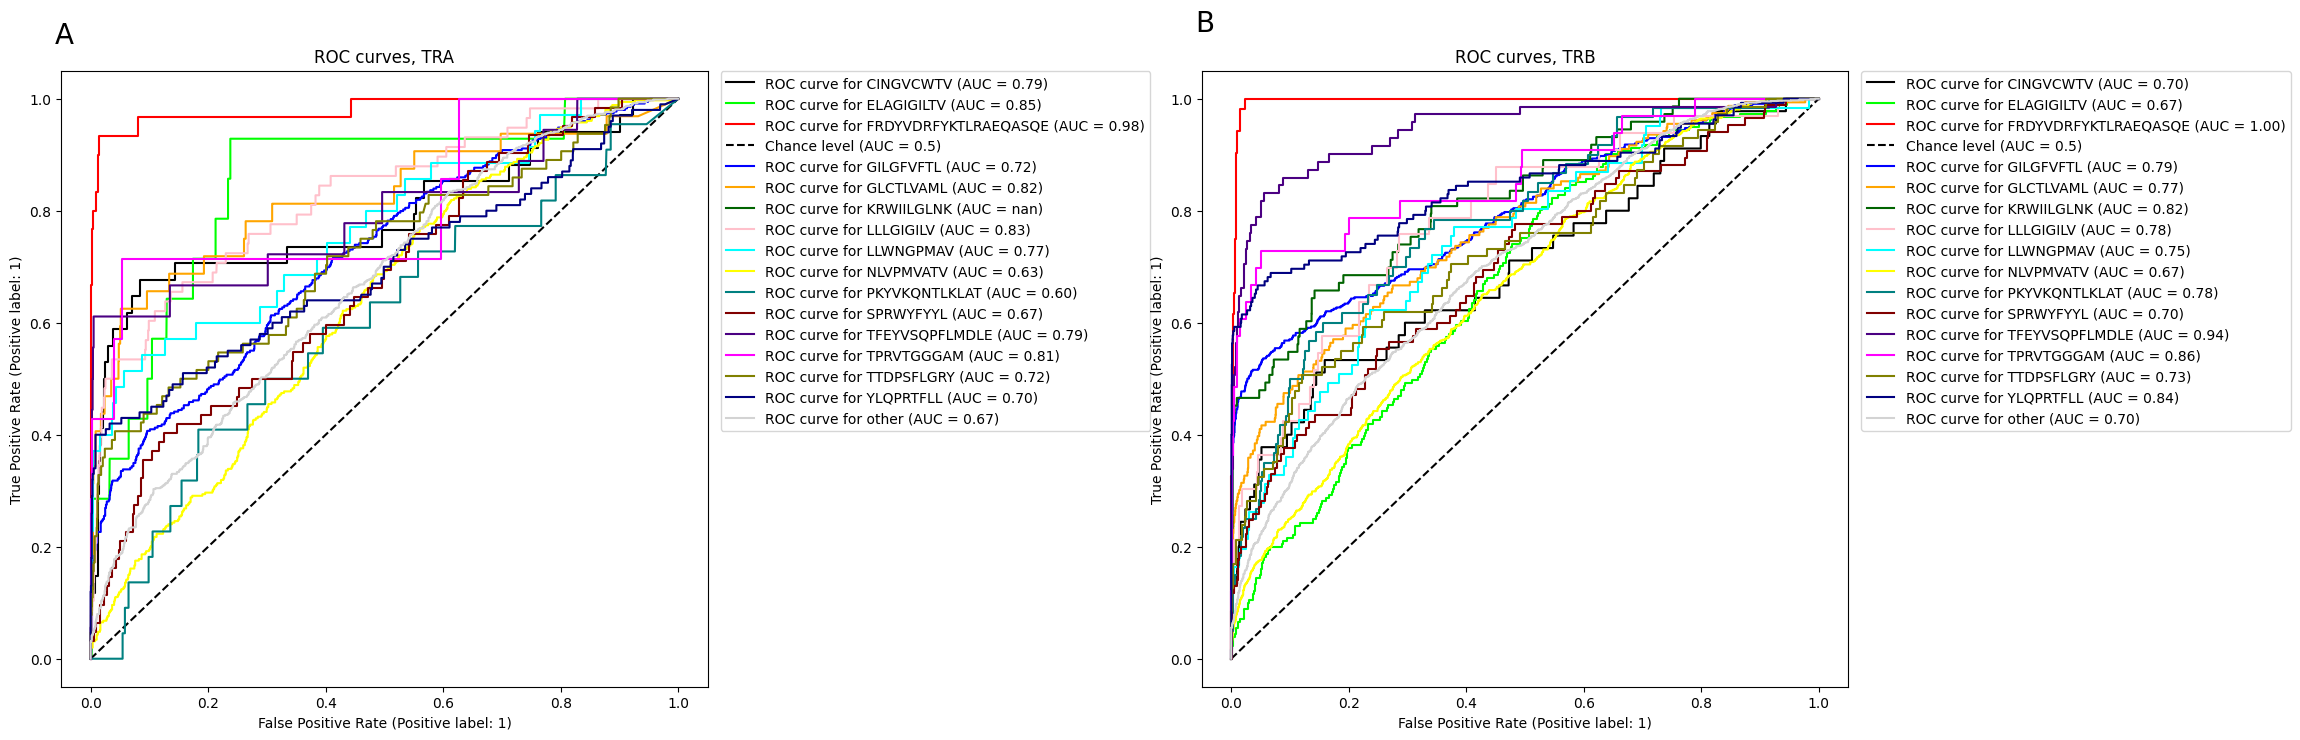

In [50]:



fig = plt.figure(figsize=(26,8))

delta_x=-0.01
delta_y=1.1
font_size=20


gs00 = fig.add_gridspec(1, 9)

ax1 = fig.add_subplot(gs00[:3])
ax2 = fig.add_subplot(gs00[5:8])



clf.roc_auc('TRA',custom_palette=custom_palette, ax=ax1)

ax1.text(delta_x, delta_y - 0.02, 'A',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax1.transAxes,
        size=font_size)
#ax1.set_title('tcr counts for each epitope')

clf.roc_auc('TRB',custom_palette=custom_palette, ax=ax2)

ax2.text(delta_x, delta_y, 'B',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax2.transAxes,
        size=font_size)
#ax2.set_title('top count epitopes')


plt.savefig("results/figures/fig6.png")
plt.show()





In [ ]:

fig = plt.figure(figsize=(20,27))

delta_x=-0.01
delta_y=1.1
font_size=20


gs00 = fig.add_gridspec(4, 3)

ax1 = fig.add_subplot(gs00[:3, 0])
ax2 = fig.add_subplot(gs00[3, 0])
ax3 = fig.add_subplot(gs00[0, 1])
ax4 = fig.add_subplot(gs00[1, 1])
ax5 = fig.add_subplot(gs00[2, 1])
ax6 = fig.add_subplot(gs00[3, 1])


sns.histplot(data = data_prebuilt, y = str(label+'_freq_20'),hue='chain',multiple='stack', ax=ax1)

ax1.text(delta_x, delta_y - 0.08, 'A',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax1.transAxes,
        size=font_size)
ax1.set_title('tcr counts for each epitope')

sns.histplot(data = data_prebuilt, y = str(label+'_freq_1000'),hue='chain',multiple='stack', ax=ax2)

ax2.text(delta_x, delta_y, 'B',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax2.transAxes,
        size=font_size)
ax2.set_title('top count epitopes')

chain = 'TRA'
tcremp_code3.tsne_plot(pd.merge(tcremp.tsne[chain],tcremp.annot[chain]), str(label+'_freq_1000'),f'VDJdb,{chain}, TSNE colored by top count epitopes',custom_palette=custom_palette,ax=ax3)
ax3.text(delta_x, delta_y, 'C',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax3.transAxes,
        size=font_size)

chain = 'TRB'
tcremp_code3.tsne_plot(pd.merge(tcremp.tsne[chain],tcremp.annot[chain]), str(label+'_freq_1000'), f'VDJdb,{chain}, TSNE colored by top count epitopes',custom_palette=custom_palette,ax=ax4)

ax4.text(delta_x, delta_y, 'D',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax4.transAxes,
        size=font_size)


label_cl = label+'_freq_1000'
model_name = 'RF_' + label_cl
clsf_dict[model_name]= {'model':{},'roc_auc':{}}

chain = 'TRA'
max_depth = 20


y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]


model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = clf_model(model,y_data, X_data , annotation_id, chain,ax=ax5)

ax5.text(delta_x, delta_y, 'E',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax5.transAxes,
        size=font_size)


chain = 'TRB'
max_depth = 20


y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]


model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = clf_model(model,y_data, X_data , annotation_id, chain,ax=ax6)

ax6.text(delta_x, delta_y, 'F',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax6.transAxes,
        size=font_size)

plt.savefig("results/figures/fig2.png")
plt.show()





In [ ]:

fig = plt.figure(figsize=(20,27))

delta_x=-0.01
delta_y=1.1
font_size=20


gs00 = fig.add_gridspec(4, 3)

ax1 = fig.add_subplot(gs00[:3, 0])
ax2 = fig.add_subplot(gs00[3, 0])
ax3 = fig.add_subplot(gs00[0, 1])
ax4 = fig.add_subplot(gs00[1, 1])
ax5 = fig.add_subplot(gs00[2, 1])
ax6 = fig.add_subplot(gs00[3, 1])


sns.histplot(data = data_prebuilt, y = str(label+'_freq_20'),hue='chain',multiple='stack', ax=ax1)

ax1.text(delta_x, delta_y - 0.08, 'A',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax1.transAxes,
        size=font_size)
ax1.set_title('tcr counts for each epitope')

sns.histplot(data = data_prebuilt, y = str(label+'_freq_1000'),hue='chain',multiple='stack', ax=ax2)

ax2.text(delta_x, delta_y, 'B',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax2.transAxes,
        size=font_size)
ax2.set_title('top count epitopes')

chain = 'TRA'
tcremp_code3.tsne_plot(pd.merge(tcremp.tsne[chain],tcremp.annot[chain]), str(label+'_freq_1000'),f'VDJdb,{chain}, TSNE colored by top count epitopes',custom_palette=custom_palette,ax=ax3)
ax3.text(delta_x, delta_y, 'C',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax3.transAxes,
        size=font_size)

chain = 'TRB'
tcremp_code3.tsne_plot(pd.merge(tcremp.tsne[chain],tcremp.annot[chain]), str(label+'_freq_1000'), f'VDJdb,{chain}, TSNE colored by top count epitopes',custom_palette=custom_palette,ax=ax4)

ax4.text(delta_x, delta_y, 'D',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax4.transAxes,
        size=font_size)


label_cl = label+'_freq_1000'
model_name = 'RF_' + label_cl
clsf_dict[model_name]= {'model':{},'roc_auc':{}}

chain = 'TRA'
max_depth = 20


y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]


model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = clf_model_proba(model,y_data, X_data , annotation_id, chain,ax=ax5)

ax5.text(delta_x, delta_y, 'E',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax5.transAxes,
        size=font_size)


chain = 'TRB'
max_depth = 20


y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]


model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = clf_model_proba(model,y_data, X_data , annotation_id, chain,ax=ax6)

ax6.text(delta_x, delta_y, 'F',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax6.transAxes,
        size=font_size)


#plt.savefig("tcremp_outputs/figures/fig2.svg")
#plt.savefig("tcremp_outputs/figures/fig2.pdf")
#plt.savefig("tcremp_outputs/figures/fig2.png")
plt.show()





In [ ]:
label_high_s_1000

In [ ]:

max_depth = 100
fig = plt.figure(figsize=(20,22))

delta_x=-0.01
delta_y=1.1
font_size=20

gs00 = fig.add_gridspec(4, 3)

ax1 = fig.add_subplot(gs00[:3, 0])
ax2 = fig.add_subplot(gs00[3, 0])
ax3 = fig.add_subplot(gs00[0, 1])
ax4 = fig.add_subplot(gs00[1, 1])
ax5 = fig.add_subplot(gs00[2, 1])
ax6 = fig.add_subplot(gs00[3, 1])

sns.histplot(data = data_prebuilt, y = 'antigen.species',hue='chain',multiple='stack', ax=ax1)

ax1.text(delta_x, delta_y - 0.08, 'A',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax1.transAxes,
        size=font_size)
ax1.set_title('tcr counts for each species')

sns.histplot(data = data_prebuilt, y = label_high_s_1000,hue='chain',multiple='stack', ax=ax2)

ax2.text(delta_x, delta_y, 'B',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax2.transAxes,
        size=font_size)
ax2.set_title('top count species')

chain = 'TRA'
tcremp_code3.tsne_plot(pd.merge(tcremp.tsne[chain],tcremp.annot[chain]), str(label_high_s_1000),f'VDJdb,{chain}, TSNE colored by top antigen.species',ax=ax3)

ax3.text(delta_x, delta_y, 'C',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax3.transAxes,
        size=font_size)

chain = 'TRB'
tcremp_code3.tsne_plot(pd.merge(tcremp.tsne[chain],tcremp.annot[chain]), str(label_high_s_1000), f'VDJdb,{chain}, TSNE colored by top antigen.species',ax=ax4)

ax4.text(delta_x, delta_y, 'D',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax4.transAxes,
        size=font_size)


label_cl = label_high_s_1000
model_name = 'RF_' + label_cl
clsf_dict[model_name]= {'model':{},'roc_auc':{}}

chain = 'TRA'



y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]


model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = clf_model_proba(model,y_data, X_data , annotation_id, chain,ax=ax5)

ax5.text(delta_x, delta_y, 'E',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax5.transAxes,
        size=font_size)

chain = 'TRB'



y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]


model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = clf_model_proba(model,y_data, X_data , annotation_id, chain,ax=ax6)

ax6.text(delta_x, delta_y, 'F',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax6.transAxes,
        size=font_size)


plt.savefig("results/figures/fig2.2.png")
plt.show()

In [ ]:

fig = plt.figure(figsize=(20,22))

delta_x=-0.01
delta_y=1.1
font_size=20

gs00 = fig.add_gridspec(4, 3)

ax1 = fig.add_subplot(gs00[:3, 0])
ax2 = fig.add_subplot(gs00[3, 0])
ax3 = fig.add_subplot(gs00[0, 1])
ax4 = fig.add_subplot(gs00[1, 1])
ax5 = fig.add_subplot(gs00[2, 1])
ax6 = fig.add_subplot(gs00[3, 1])

sns.histplot(data = data_prebuilt, y = 'antigen.species',hue='chain',multiple='stack', ax=ax1)

ax1.text(delta_x, delta_y - 0.08, 'A',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax1.transAxes,
        size=font_size)
ax1.set_title('tcr counts for each species')

sns.histplot(data = data_prebuilt, y = label_high_s_1000,hue='chain',multiple='stack', ax=ax2)

ax2.text(delta_x, delta_y, 'B',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax2.transAxes,
        size=font_size)
ax2.set_title('top count species')

chain = 'TRA'
tcremp_code3.tsne_plot(pd.merge(tcremp.tsne[chain],tcremp.annot[chain]), str(label_high_s_1000),f'VDJdb,{chain}, TSNE colored by top antigen.species',ax=ax3)

ax3.text(delta_x, delta_y, 'C',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax3.transAxes,
        size=font_size)

chain = 'TRB'
tcremp_code3.tsne_plot(pd.merge(tcremp.tsne[chain],tcremp.annot[chain]), str(label_high_s_1000), f'VDJdb,{chain}, TSNE colored by top antigen.species',ax=ax4)

ax4.text(delta_x, delta_y, 'D',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax4.transAxes,
        size=font_size)


label_cl = label_high_s_1000
model_name = 'RF_' + label_cl
clsf_dict[model_name]= {'model':{},'roc_auc':{}}

chain = 'TRA'
c=5


y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]


model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = clf_model_proba(model,y_data, X_data , annotation_id, chain,ax=ax5)

ax5.text(delta_x, delta_y, 'E',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax5.transAxes,
        size=font_size)

chain = 'TRB'



y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]


model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = clf_model_proba(model,y_data, X_data , annotation_id, chain,ax=ax6)

ax6.text(delta_x, delta_y, 'F',
     horizontalalignment='left',
     verticalalignment='top',
    transform=ax6.transAxes,
        size=font_size)


plt.savefig("results/figures/fig2.2.png")
plt.show()

In [ ]:
chain = 'TRA'
tcremp_code2.tsne_plot(pd.concat([tcremp['tsne'][chain],tcremp['annot'][chain]],axis=1), str(label+'_freq_1000'), f'VDJdb,{chain}', f'TSNE colored by {str(label+"_freq_1000")}')

In [ ]:
chain = 'TRB'
tcremp_code2.tsne_plot(pd.concat([tcremp['tsne'][chain],tcremp['annot'][chain]],axis=1), str(label+'_freq_1000'), f'VDJdb,{chain}', f'TSNE colored by {str(label+"_freq_1000")}')

In [ ]:
chain = 'TRB'
tcremp_code2.tsne_plot(pd.concat([tcremp['tsne'][chain],tcremp['annot'][chain]],axis=1), str(label+'_freq_200'), f'VDJdb,{chain}', f'TSNE colored by {str(label+"_freq_200")}')

In [ ]:
model_name = 'RF_label_1000'
label_cl = label+'_freq_1000'
clsf_dict[model_name]= {'model':{},'roc_auc':{}}

chain = 'TRA'
max_depth = 20


y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]


model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = tcremp_code2.clf_model(model,y_data, X_data , annotation_id, chain)

chain = 'TRB'
max_depth = 20

y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]


model = RandomForestClassifier(max_depth=max_depth, random_state=0)
clsf_dict[model_name]['model'][chain], clsf_dict[model_name]['roc_auc'][chain] = tcremp_code2.clf_model(model,y_data, X_data , annotation_id, chain)


In [ ]:
label_cl = label
model_name = 'KMeans'
threshold = 0.6
clstr_dict[model_name]= {'binom_res':{},'clstr_metrics':{},'binom_res_train':{},'clstr_metrics_train':{}}
tcremp['clstr_labels'][model_name]={}




chain = 'TRA'
n_clusters = 5295
random_state = 8

y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]#.drop(annotation_id, axis=1, errors = 'ignore')

model =  KMeans(n_clusters=n_clusters, random_state=random_state)
tcremp['clstr_labels'][model_name][chain] = tcremp_code2.clstr_model(model, X_data , annotation_id)

clstr_dict[model_name]['binom_res'][chain] = tcremp_code2.binominal_test(pd.merge(tcremp['clstr_labels'][model_name][chain],tcremp['annot'][chain]), 'cluster', label_cl)
clstr_dict[model_name]['binom_res'][chain]['enriched_clstr'] =clstr_dict[model_name]['binom_res'][chain].apply(lambda x:1 
                                                                                                               if (x.fraction_matched>=threshold)
                                                                                                               and (x.total_cluster>2) else 0,axis=1)
clstr_dict[model_name]['clstr_metrics'][chain] = tcremp_code2.clstr_metrics(tcremp['annot'][chain][label_cl],tcremp['clstr_labels'][model_name][chain]['cluster'])



tcremp['clstr_labels'][model_name][chain] = tcremp['clstr_labels'][model_name][chain].merge(clstr_dict[model_name]['binom_res'][chain].rename({label_cl:'label_cluster'},axis=1)
                                                                                            , on='cluster',how='left').sort_values(annotation_id).reset_index(drop=True)

print('mean fraction_matched: ' + str(statistics.mean(clstr_dict[model_name]['binom_res'][chain]['fraction_matched'])))
print('median fraction_matched: ' + str(statistics.median(clstr_dict[model_name]['binom_res'][chain]['fraction_matched'])))
print(clstr_dict[model_name]['clstr_metrics'][chain])


sns.histplot(tcremp['clstr_labels'][model_name][chain]['enriched_clstr'].astype(str))
plt.title('count of tcrs in enriched clusters')
tcremp_code2.tsne_plot(pd.merge(tcremp['tsne'][chain],tcremp['clstr_labels'][model_name][chain],on=annotation_id), 'enriched_clstr', f'10x ,{chain}', f'TSNE colored by enriched_clstr', True)

chain = 'TRB'
n_clusters = 10616
random_state = 8

y_data = tcremp['annot'][chain][label_cl]
X_data = tcremp['pca'][chain]#.drop(annotation_id, axis=1, errors = 'ignore')

model =  KMeans(n_clusters=n_clusters, random_state=random_state)
tcremp['clstr_labels'][model_name][chain] = tcremp_code2.clstr_model(model, X_data , annotation_id)

clstr_dict[model_name]['binom_res'][chain] = tcremp_code2.binominal_test(pd.merge(tcremp['clstr_labels'][model_name][chain],tcremp['annot'][chain]), 'cluster', label_cl)
clstr_dict[model_name]['binom_res'][chain]['enriched_clstr'] =clstr_dict[model_name]['binom_res'][chain].apply(lambda x:1 
                                                                                                               if (x.fraction_matched>=threshold)
                                                                                                               and (x.total_cluster>2) else 0,axis=1)
clstr_dict[model_name]['clstr_metrics'][chain] = tcremp_code2.clstr_metrics(tcremp['annot'][chain][label_cl],tcremp['clstr_labels'][model_name][chain]['cluster'])



tcremp['clstr_labels'][model_name][chain] = tcremp['clstr_labels'][model_name][chain].merge(clstr_dict[model_name]['binom_res'][chain].rename({label_cl:'label_cluster'},axis=1)
                                                                                            , on='cluster',how='left').sort_values(annotation_id).reset_index(drop=True)

print('mean fraction_matched: ' + str(statistics.mean(clstr_dict[model_name]['binom_res'][chain]['fraction_matched'])))
print('median fraction_matched: ' + str(statistics.median(clstr_dict[model_name]['binom_res'][chain]['fraction_matched'])))
print(clstr_dict[model_name]['clstr_metrics'][chain])


sns.histplot(tcremp['clstr_labels'][model_name][chain]['enriched_clstr'].astype(str))
plt.title('count of tcrs in enriched clusters')
tcremp_code2.tsne_plot(pd.merge(tcremp['tsne'][chain],tcremp['clstr_labels'][model_name][chain],on=annotation_id), 'enriched_clstr', f'10x ,{chain}', f'TSNE colored by enriched_clstr', True)
